# Análisis Exploratorio de Datos de VitalMind AI

## Proyecto

**VitalMind AI**

## Objetivo

Realizar un análisis exploratorio del dataset procesado de VitalMind AI para conocer su estructura, calidad, distribución, relaciones entre variables y comportamiento de las clases de riesgo antes del entrenamiento de modelos.

## Fuente de datos

El análisis utiliza el archivo:

```text
ml-service/data/processed/vitalmind_dataset_processed.csv
```

El dataset contiene registros sintéticos diarios relacionados con:

Perfil del usuario.
- Hábitos de bienestar.
- Síntomas y signos físicos.
- Estado emocional.
- Puntajes derivados.
- Nivel preventivo de riesgo.
- Anomalías sintéticas.
- Alcance inicial

En este notebook se analizarán:

- Dimensiones y tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Estadísticas descriptivas.
- Distribución de clases.
- Distribución de variables numéricas y categóricas.
- Relaciones entre hábitos, emociones, síntomas y riesgo.
- Correlaciones.
- Comportamiento temporal.
- Anomalías sintéticas.


---

## 1. Importación de librerías

Se utilizarán librerías para:

- Manipulación de datos.
- Cálculos numéricos.
- Visualización.
- Configuración del entorno del notebook.



In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Librerías importadas correctamente.")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Librerías importadas correctamente.
Python: 3.13.9
NumPy: 2.3.5
Pandas: 2.3.3


## 2. Definición de rutas

Se construirá la ruta del dataset de manera relativa para evitar depender de una ruta absoluta del equipo local.

El notebook se encuentra dentro de:

```text
ml-service/app/notebooks
```

El dataset procesado se encuentra dentro de:

```text
ml-service/data/processed
```


In [6]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_SERVICE_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "ml-service").exists():
    ML_SERVICE_DIR = NOTEBOOK_DIR / "ml-service"
else:
    ML_SERVICE_DIR = NOTEBOOK_DIR.parent

DATASET_PATH = (
    ML_SERVICE_DIR
    /".."
    / "data"
    / "processed"
    / "vitalmind_dataset_processed.csv"
)

print("Directorio actual:")
print(NOTEBOOK_DIR)

print("\nRuta del dataset:")
print(DATASET_PATH)

print("\n¿Existe el archivo?")
print(DATASET_PATH.exists())

Directorio actual:
C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\notebooks

Ruta del dataset:
C:\Users\otero\OneDrive\Desktop\9A-IDGS-ECBD-VitalMind-\ml-service\app\..\data\processed\vitalmind_dataset_processed.csv

¿Existe el archivo?
True


## 3. Carga del dataset

El archivo procesado se cargará utilizando `pandas`.

La columna `log_date` se convertirá directamente a tipo fecha para facilitar el análisis temporal.

In [10]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset procesado en:\n{DATASET_PATH}"
    )

df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["log_date"],
)

print("Dataset cargado correctamente.")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Registros: 5,000
Columnas: 35


## 4. Vista inicial del dataset

Se mostrarán los primeros registros para comprobar:

- Nombres de columnas.
- Orden de variables.
- Formato de los valores.
- Presencia de variables derivadas.
- Variables objetivo.

In [11]:
df.head()

,record_id,user_id,log_date,profile_type,age,height_cm,weight_profile_kg,weight_kg,bmi,water_glasses,water_liters,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,mood,stress_level,energy_level,sleep_quality,sleep_score,activity_score,nutrition_score,emotional_score,physical_condition_score,wellbeing_score,risk_factors_count,risk_level,is_anomaly,weight_source
0,REC_000001,USR_0001,2026-04-02,healthy,40,164.40,68.30,68.40,25.31,10.97,2.74,40.60,7.50,2,17.00,1,37.00,118,76,79,67,Bien,2,7,6,76.58,67.72,76.83,72.17,97.00,80.85,0,low,False,symptom_log
1,REC_000002,USR_0001,2026-04-07,healthy,40,164.40,68.30,68.50,25.34,6.85,1.71,32.60,7.30,4,27.80,0,37.30,109,58,69,87,Bien,1,6,6,75.43,54.36,92.09,74.07,99.33,72.73,0,low,False,symptom_log
2,REC_000003,USR_0001,2026-04-09,healthy,40,164.40,68.30,68.70,25.42,8.73,2.18,16.40,8.40,2,18.70,1,36.70,108,75,92,94,Bien,1,5,8,83.46,27.26,82.99,73.07,97.00,69.17,0,medium,False,symptom_log
3,REC_000004,USR_0001,2026-04-20,healthy,40,164.40,68.30,68.70,25.42,7.96,1.99,37.30,8.40,3,21.50,0,37.10,115,65,116,59,Muy bien,1,7,9,92.23,62.10,99.72,87.61,99.60,91.34,0,low,False,symptom_log
4,REC_000005,USR_0001,2026-04-26,healthy,40,164.40,68.30,68.70,25.42,8.24,2.06,45.10,8.20,4,6.40,0,36.80,115,69,101,86,Bien,2,6,5,76.24,75.13,99.34,66.59,100.00,76.45,0,low,False,symptom_log


In [12]:
df.tail()

,record_id,user_id,log_date,profile_type,age,height_cm,weight_profile_kg,weight_kg,bmi,water_glasses,water_liters,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,mood,stress_level,energy_level,sleep_quality,sleep_score,activity_score,nutrition_score,emotional_score,physical_condition_score,wellbeing_score,risk_factors_count,risk_level,is_anomaly,weight_source
4995,REC_004996,USR_0250,2026-05-31,poor_habits,26,149.20,45.50,46.30,20.80,1.53,0.38,37.60,6.00,1,0.00,5,36.90,111,77,63,79,Mal,7,2,5,55.40,62.60,25.52,30.77,84.51,52.66,3,medium,False,symptom_log
4996,REC_004997,USR_0250,2026-06-14,poor_habits,26,149.20,45.50,46.20,20.75,2.45,0.61,0.60,6.60,1,12.70,7,36.60,129,86,110,105,Muy mal,7,2,5,61.72,1.04,31.84,22.56,77.00,35.62,5,high,False,symptom_log
4997,REC_004998,USR_0250,2026-06-20,poor_habits,26,149.20,45.50,46.50,20.89,5.11,1.28,17.30,4.40,0,0.00,7,36.60,118,79,90,92,Mal,8,1,4,31.57,28.86,35.13,22.32,79.00,39.33,6,high,False,symptom_log
4998,REC_004999,USR_0250,2026-06-22,poor_habits,26,149.20,45.50,45.50,20.44,3.28,0.82,10.90,3.60,3,11.20,6,36.90,115,79,116,84,Muy mal,7,1,4,20.60,18.22,67.55,17.44,82.00,32.06,4,high,False,profile_fallback
4999,REC_005000,USR_0250,2026-06-29,poor_habits,26,149.20,45.50,46.30,20.80,4.53,1.13,0.00,4.10,1,3.50,3,37.10,106,74,88,70,Muy mal,7,1,4,31.25,0.00,46.14,23.08,91.00,32.56,4,high,False,symptom_log


## 5. Dimensiones y estructura general.

In [13]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Celdas totales: {df.shape[0]*df.shape[1]:,}")

Filas: 5,000
Columnas: 35
Celdas totales: 175,000


In [15]:
column_summary = pd.DataFrame(
    {
        "columna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "valores_no_nulos": df.notna().sum().values,
        "valores_nulos": df.isna().sum().values,
        "valores_unicos": df.nunique(dropna=True).values,
    }
)

column_summary

,columna,tipo,valores_no_nulos,valores_nulos,valores_unicos
0,record_id,object,5000,0,5000
1,user_id,object,5000,0,250
2,log_date,datetime64[ns],5000,0,90
3,profile_type,object,5000,0,4
4,age,int64,5000,0,49
5,height_cm,float64,5000,0,182
6,weight_profile_kg,float64,5000,0,210
7,weight_kg,float64,5000,0,698
8,bmi,float64,5000,0,1400
9,water_glasses,float64,5000,0,1171


## 6. Información técnica del dataset

La función `info()` permite revisar: 

- Tipos de datos.
- Cantidad de valores no nulos.
- Uso apropiado de memoria.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   record_id                 5000 non-null   object        
 1   user_id                   5000 non-null   object        
 2   log_date                  5000 non-null   datetime64[ns]
 3   profile_type              5000 non-null   object        
 4   age                       5000 non-null   int64         
 5   height_cm                 5000 non-null   float64       
 6   weight_profile_kg         5000 non-null   float64       
 7   weight_kg                 5000 non-null   float64       
 8   bmi                       5000 non-null   float64       
 9   water_glasses             5000 non-null   float64       
 10  water_liters              5000 non-null   float64       
 11  exercise_minutes          5000 non-null   float64       
 12  sleep_hours         

## 7. Identificación de variables

Las columnas se agruparán según su función dentro del dataset.

In [17]:
identifier_columns = [
    "record_id",
    "user_id",
    "log_date",
]

profile_columns = [
    "profile_type",
    "age",
    "height_cm",
    "weight_profile_kg",
    "weight_kg",
    "weight_source",
    "bmi",
]

habit_columns = [
    "water_glasses",
    "water_liters",
    "exercise_minutes",
    "sleep_hours",
    "healthy_meals_count",
    "meditation_minutes",
]

physical_columns = [
    "pain",
    "temperature_c",
    "systolic_mmhg",
    "diastolic_mmhg",
    "glucose_mg_dl",
    "heart_rate_bpm",
]

emotional_columns = [
    "mood",
    "stress_level",
    "energy_level",
    "sleep_quality",
]

score_columns = [
    "sleep_score",
    "activity_score",
    "nutrition_score",
    "emotional_score",
    "physical_condition_score",
    "wellbeing_score",
]

target_columns = [
    "risk_factors_count",
    "risk_level",
    "is_anomaly",
]

all_grouped_columns = (
    identifier_columns
    + profile_columns
    + habit_columns
    + physical_columns
    + emotional_columns
    + score_columns
    + target_columns
)

missing_from_groups = sorted(
    set(df.columns) - set(all_grouped_columns)
)

unknown_in_dataset = sorted(
    set(all_grouped_columns) - set(df.columns)
)

print("Columnas sin grupo:")
print(missing_from_groups if missing_from_groups else "Ninguna")

print("\nColumnas definidas que no existen en el dataset:")
print(unknown_in_dataset if unknown_in_dataset else "Ninguna")

Columnas sin grupo:
Ninguna

Columnas definidas que no existen en el dataset:
Ninguna


## Hallazgos preliminares

En esta primera revisión se espera comprobar que:

- El dataet contiene 5000 registros.
- Existen 35 columnas procesadas.
- `log_date` tiene un tipo adecuado para análisis temporal.
- no existen valores faltantes en el dataset procesado.
- Las columnas se encuentran organizadas de acuerdo con su función.
- Las variables objetivo son `risk_level`, `wellbeing_score` e `is_anomaly`

## 8. Calidad general del dataset

Se revisarán:

- Valores faltantes.
- Registros duplicados.
- Identificadores repetidos.
- Duplicados por usuario y fecha.
- Fechas disponibles.

In [19]:
missing_values=(
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage=(
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame(
    {
        "valores_faltantes":missing_values,
        "porcentaje":missing_percentage,
    }
)
missing_summary.head(15)

,valores_faltantes,porcentaje
record_id,0,0.00
activity_score,0,0.00
heart_rate_bpm,0,0.00
mood,0,0.00
stress_level,0,0.00
energy_level,0,0.00
sleep_quality,0,0.00
sleep_score,0,0.00
nutrition_score,0,0.00
diastolic_mmhg,0,0.00


In [21]:
print(f"Valores faltantes totales: {df.isna().sum().sum():,}")
print(f"Filas compleyamente duplicadas: {df.duplicated().sum():,}")
print(f"record_id duplicados: {df['record_id'].duplicated().sum():,}")

daily_duplicates = df.duplicated(
    subset=["user_id","log_date"]
).sum()

print("Duplicados por user_id y log_date: "
     f"{daily_duplicates:,}"
     )

Valores faltantes totales: 0
Filas compleyamente duplicadas: 0
record_id duplicados: 0
Duplicados por user_id y log_date: 0


In [23]:
print(f"Fecha mímima: {df['log_date'].min().date()}")
print(f"Fecha máxima: {df['log_date'].max().date()}")
print(f"Fechas únicas: {df['log_date'].nunique()}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")
print(
    "Promedio de registros por usuario: "
    f"{df.groupby('user_id').size().mean():.2f}"
)

Fecha mímima: 2026-04-01
Fecha máxima: 2026-06-29
Fechas únicas: 90
Usuarios únicos: 250
Promedio de registros por usuario: 20.00


### Hallazgo de calidad

El dataser procesado no presenta valores faltantes ni registros duplicados.

Cada combinación de `user_id` y `log_date` es única, lo que confirma que la unidad de observación corresponde a un registro diario por usuario.

## 9. Estadísticas descriptivas

Se analizarán las variables numéricas para identificar:

- Promedio.
- Desviación estándar.
- Valores mínimo y máximos.
- Cuartiles.
- Posibles valores extremos.
  

In [24]:
numeric_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Variables numéricas:{len(numeric_columns)}")
print(numeric_columns)

Variables numéricas:27
['age', 'height_cm', 'weight_profile_kg', 'weight_kg', 'bmi', 'water_glasses', 'water_liters', 'exercise_minutes', 'sleep_hours', 'healthy_meals_count', 'meditation_minutes', 'pain', 'temperature_c', 'systolic_mmhg', 'diastolic_mmhg', 'glucose_mg_dl', 'heart_rate_bpm', 'stress_level', 'energy_level', 'sleep_quality', 'sleep_score', 'activity_score', 'nutrition_score', 'emotional_score', 'physical_condition_score', 'wellbeing_score', 'risk_factors_count']


In [26]:
descriptive_statistics = (
    df[numeric_columns]
    .describe()
    .T
)

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
age,"5,000.00",36.64,13.15,18.00,26.00,36.00,46.00,74.00
height_cm,"5,000.00",166.33,10.67,140.00,159.00,166.30,173.30,191.20
weight_profile_kg,"5,000.00",72.14,18.57,40.00,58.10,70.90,83.80,134.40
weight_kg,"5,000.00",72.14,18.61,40.00,58.20,70.80,83.60,134.50
bmi,"5,000.00",25.88,5.40,16.16,21.83,25.29,29.40,44.33
water_glasses,"5,000.00",6.24,2.79,0.00,4.24,6.27,8.23,14.25
water_liters,"5,000.00",1.56,0.70,0.00,1.06,1.57,2.06,3.56
exercise_minutes,"5,000.00",27.65,21.64,0.00,8.28,25.50,43.62,111.00
sleep_hours,"5,000.00",6.54,1.39,1.00,5.50,6.50,7.50,10.00
healthy_meals_count,"5,000.00",2.11,1.26,0.00,1.00,2.00,3.00,5.00


In [27]:
descriptive_statistics[
    ["min","25%","50%","mean","75%","max","std"]
].round(2)

,min,25%,50%,mean,75%,max,std
age,18.00,26.00,36.00,36.64,46.00,74.00,13.15
height_cm,140.00,159.00,166.30,166.33,173.30,191.20,10.67
weight_profile_kg,40.00,58.10,70.90,72.14,83.80,134.40,18.57
weight_kg,40.00,58.20,70.80,72.14,83.60,134.50,18.61
bmi,16.16,21.83,25.29,25.88,29.40,44.33,5.40
water_glasses,0.00,4.24,6.27,6.24,8.23,14.25,2.79
water_liters,0.00,1.06,1.57,1.56,2.06,3.56,0.70
exercise_minutes,0.00,8.28,25.50,27.65,43.62,111.00,21.64
sleep_hours,1.00,5.50,6.50,6.54,7.50,10.00,1.39
healthy_meals_count,0.00,1.00,2.00,2.11,3.00,5.00,1.26


### Variables categóricas

Se revisarán las categorías existentes y su frecuencia.

In [29]:
categorical_columns = df.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

print(f"Variables categóricas: {len(categorical_columns)}")
print(categorical_columns)

Variables categóricas: 7
['record_id', 'user_id', 'profile_type', 'mood', 'risk_level', 'is_anomaly', 'weight_source']


In [30]:
for column in [
    "profile_type",
    "weight_source",
    "mood",
    "risk_level",
    "is_anomaly"
]:
    print(f"\n{column}")
    print("-"* len(column))
    print(df[column].value_counts(dropna=False))


profile_type
------------
profile_type
healthy                  1776
poor_habits              1280
irregular                1229
physically_vulnerable     715
Name: count, dtype: int64

weight_source
-------------
weight_source
symptom_log         4850
profile_fallback     150
Name: count, dtype: int64

mood
----
mood
Mal         1278
Regular     1222
Bien        1221
Muy bien     732
Muy mal      547
Name: count, dtype: int64

risk_level
----------
risk_level
medium    1970
low       1849
high      1181
Name: count, dtype: int64

is_anomaly
----------
is_anomaly
False    4850
True      150
Name: count, dtype: int64


## 10. Distribución del nivel preventivo de riesgo

La variable `risk_level` es el objetivo principal del problema de clasificación.

Se analizará:

- Cantidad de registros por clase.
- Porcentaje de cada clase.
- Posible desbalance.

In [32]:
risk_counts = (
    df["risk_level"]
    .value_counts()
    .reindex(["low","medium","high"])
)

risk_pencentages = (
    df["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["low","medium","high"])
)

risk_summary = pd.DataFrame(
    {
        "registros": risk_counts,
        "porcentaje": risk_pencentages,
    }
)

risk_summary

,registros,porcentaje
risk_level,,
low,1849,36.98
medium,1970,39.40
high,1181,23.62


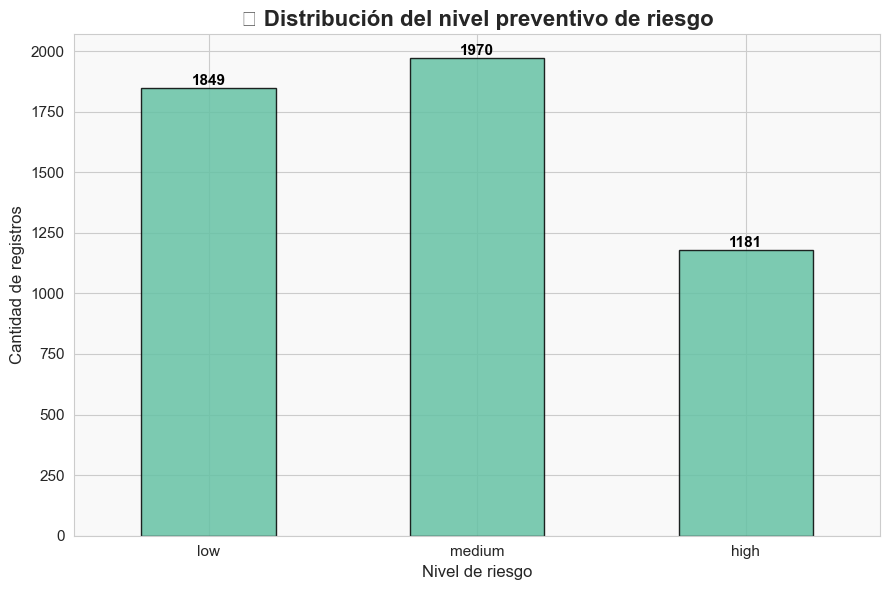

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo más moderno
sns.set_style("whitegrid")
sns.set_palette("Set2")

ax = risk_counts.plot(
    kind="bar",
    figsize=(9,6),
    edgecolor="black",   
    alpha=0.85           
)

# Títulos y etiquetas más grandes
ax.set_title("📊 Distribución del nivel preventivo de riesgo", fontsize=16, fontweight="bold")
ax.set_xlabel("Nivel de riesgo", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)

# Rotación y tamaño de ticks
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold", color="black")

# Ajuste de márgenes
plt.tight_layout()

# Fondo más atractivo
plt.gca().set_facecolor("#f9f9f9")

plt.show()


## Interpretación

La distribución no presenta una clase extremadamente minoritoria.

La clase `medium` concentra la mayor cantidad de registros, seguida de `low` y `high`

Aunque la distribución no es perfectamente equilibrada, las tres clases tienen suficiente representación para comenzar el entrenamiento y comparar modelos.

Duranre la evaluación no se utilizará únicamente `Accuracy`; también deberán revisarse `Precisión`,`Recall`,`F1-Score` y la matriz de confusión.

## 11. Distribución del puntaje de bienestar.

`wellbeing_score` es la variable objetivo propuesta para el problema de regresión.

Se analizará su distribución y relación inicial ocn los niveles de riesgo.  

In [35]:
df["wellbeing_score"].describe()

count   5,000.00
mean       61.92
std        18.72
min        15.14
25%        46.02
50%        61.05
75%        78.87
max        99.82
Name: wellbeing_score, dtype: float64

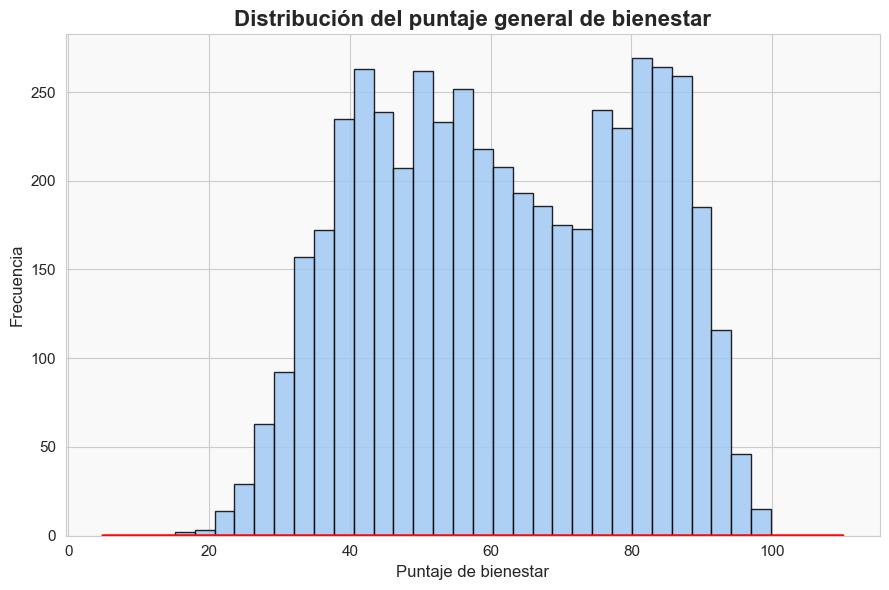

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("pastel")

ax = df["wellbeing_score"].plot(
    kind="hist",
    bins=30,
    figsize=(9,6),
    edgecolor="black",
    alpha=0.85
)


ax.set_title("Distribución del puntaje general de bienestar", fontsize=16, fontweight="bold")
ax.set_xlabel("Puntaje de bienestar", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)


ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

plt.gca().set_facecolor("#f9f9f9")

sns.kdeplot(df["wellbeing_score"], color="red", linewidth=2, ax=ax)

plt.tight_layout()
plt.show()


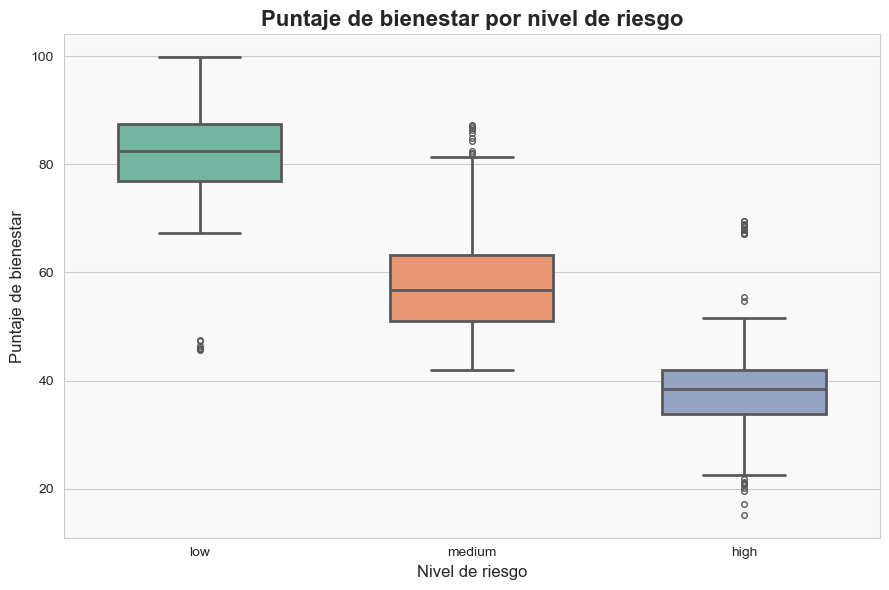

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="risk_level",
    y="wellbeing_score",
    palette="Set2",
    width=0.6,
    linewidth=2,
    fliersize=4 wellbeing_by_risk = (
    df.groupby(
        "risk_level",
        observed=True,
    )["wellbeing_score"]
    .agg(
        registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion="std",
    )
    .round(2)
)

wellbeing_by_risk
)

plt.title("Puntaje de bienestar por nivel de riesgo", fontsize=16, fontweight="bold")
plt.xlabel("Nivel de riesgo", fontsize=12)
plt.ylabel("Puntaje de bienestar", fontsize=12)

plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


In [45]:
wellbeing_by_risk = (
    df.groupby(
        "risk_level",
        observed=True,
    )["wellbeing_score"]
    .agg(
        registros="count",
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion="std",
    )
    .round(2)
)

wellbeing_by_risk

,registros,promedio,mediana,minimo,maximo,desviacion
risk_level,,,,,,
high,1181,37.76,38.46,15.14,69.51,6.47
low,1849,82.25,82.43,45.64,99.82,6.98
medium,1970,57.33,56.83,42.03,87.21,7.70


### Interpretación inicial

Se espera observar una disminución del puntaje de bienestar al pasar de riesgo `low` a `medium` y `high`.

Sin embargo, ambas variables no deben considerarse independientes, debido a que `risk_level` fue generado inicialmente utilizando `wellbeing_score` y factores adicionales.

Por esta razón, `wellbeing_score` deberá excluirse de las características del clasificador de riesgo paar evitar fuga de información y una relación circular.

## 12. Análisis de hábitos diarios

En esta sección se analizarán las variables relacionadas con:

- Hidratación.
- Actividad fisica.
- Sueño.
- Alimentación saludable.
- meditación.

El objetivo es conocer su distribución y su relación con el nivel preventivo de riesgo.


In [46]:
habit_summary=(
    df[habit_columns]
    .describe()
    .T[
        ["min","25%","50%","mean","75%","max","std"]
    ].round(2)
)
habit_summary

,min,25%,50%,mean,75%,max,std
water_glasses,0.00,4.24,6.27,6.24,8.23,14.25,2.79
water_liters,0.00,1.06,1.57,1.56,2.06,3.56,0.70
exercise_minutes,0.00,8.28,25.50,27.65,43.62,111.00,21.64
sleep_hours,1.00,5.50,6.50,6.54,7.50,10.00,1.39
healthy_meals_count,0.00,1.00,2.00,2.11,3.00,5.00,1.26
meditation_minutes,0.00,0.70,8.50,9.92,15.90,49.00,9.14


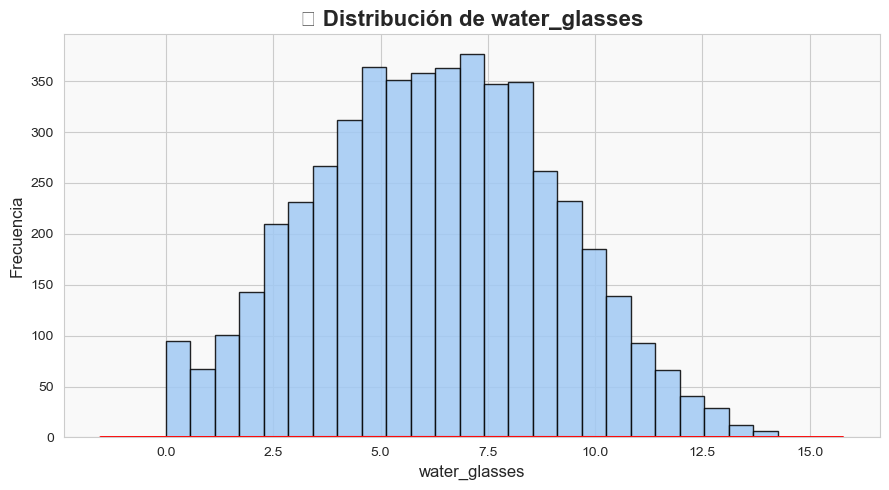

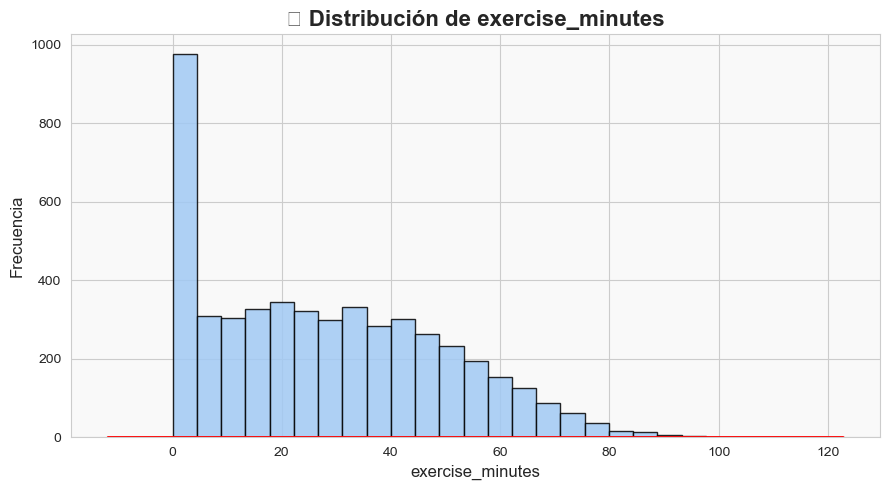

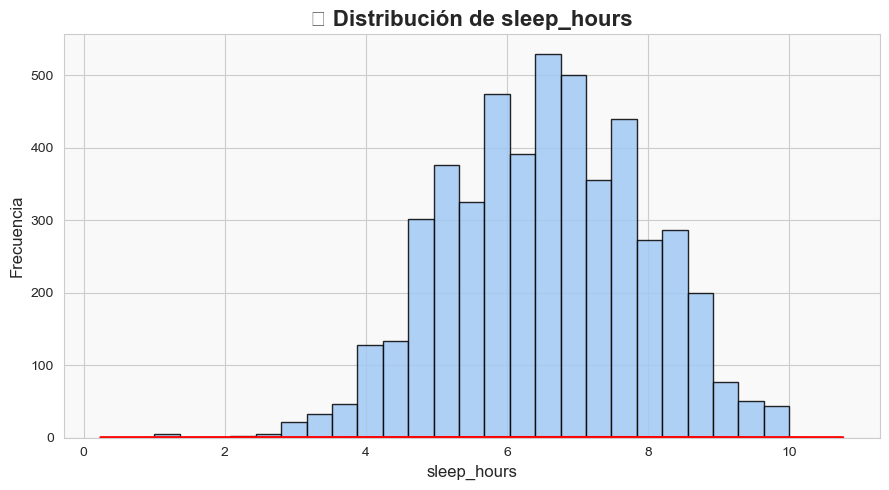

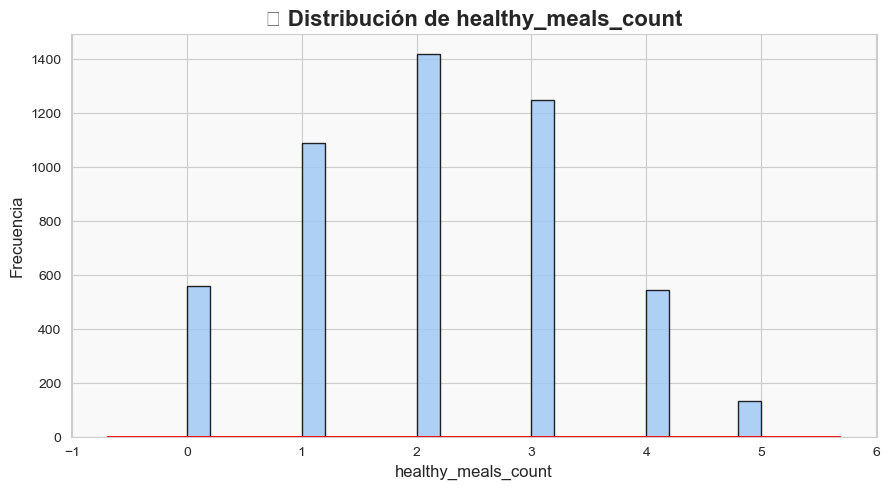

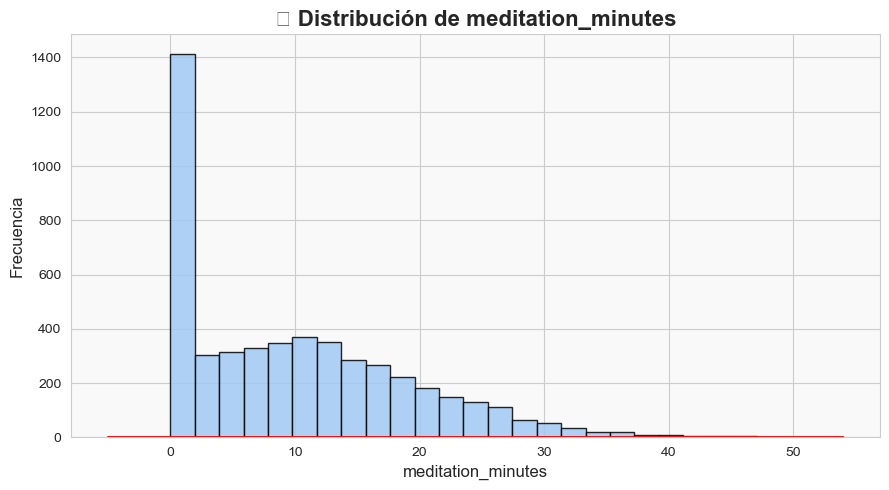

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo moderno
sns.set_style("whitegrid")
sns.set_palette("pastel")

habit_plot_columns = [
    "water_glasses",
    "exercise_minutes",
    "sleep_hours",
    "healthy_meals_count",
    "meditation_minutes",
]

for column in habit_plot_columns:
    plt.figure(figsize=(9,5))
    
    # Histograma con transparencia y bordes
    ax = df[column].plot(
        kind="hist",
        bins=25,
        edgecolor="black",
        alpha=0.85
    )
    
    # Línea de densidad para mostrar la forma de la distribución
    sns.kdeplot(df[column], color="red", linewidth=2, ax=ax)
    
    # Títulos y etiquetas más atractivos
    ax.set_title(f" Distribución de {column}", fontsize=16, fontweight="bold")
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


### Comparación de hábitos por nivel de riesgo

Se calaculará el promedio de cada hábito para los niveles `low`, `medium`,`high`

In [49]:
habit_by_risk=(
    df.groupby(
        "risk_level",
        observed=True,
    )[habit_plot_columns]
    .mean()
    .reindex(["low","medium","high"])
    .round(2)
)
habit_by_risk

,water_glasses,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes
risk_level,,,,,
low,8.34,47.51,7.70,2.92,14.59
medium,5.81,21.22,6.30,1.96,8.16
high,3.68,7.27,5.10,1.08,5.56


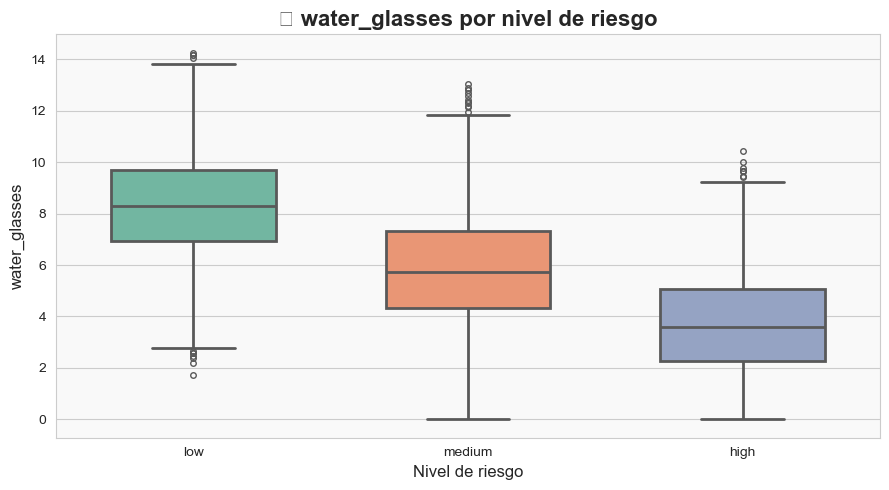

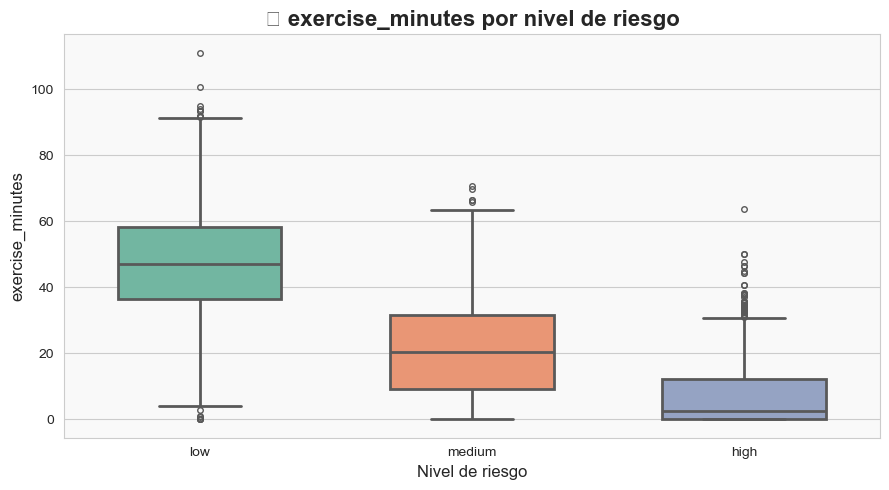

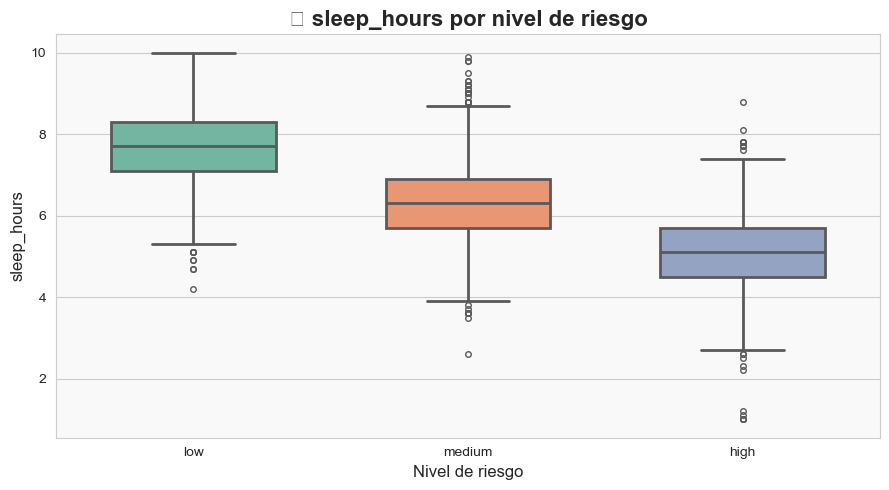

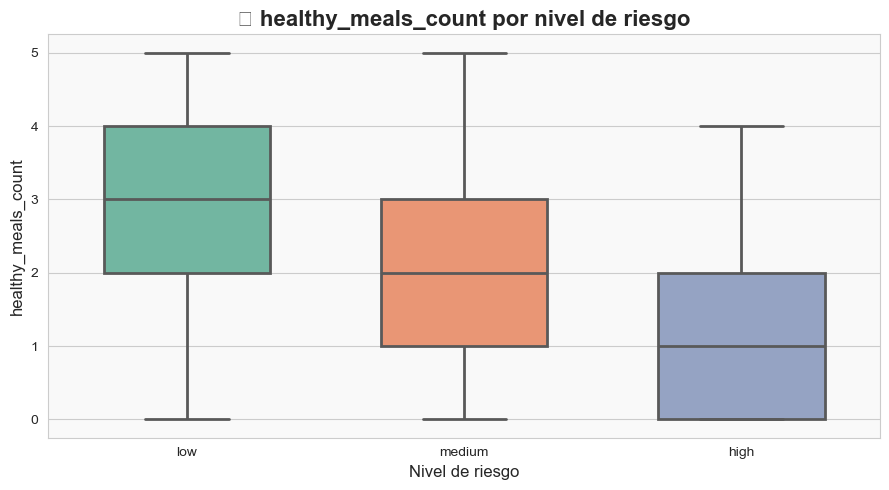

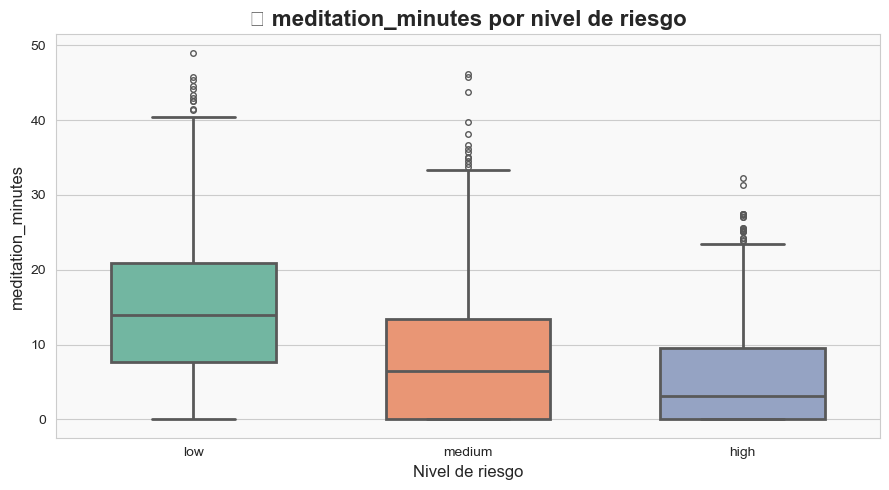

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

habit_plot_columns = [
    "water_glasses",
    "exercise_minutes",
    "sleep_hours",
    "healthy_meals_count",
    "meditation_minutes",
]

for column in habit_plot_columns:
    plt.figure(figsize=(9,5))
    
    # Boxplot estilizado
    sns.boxplot(
        data=df,
        x="risk_level",
        y=column,
        palette="Set2",
        width=0.6,
        linewidth=2,
        fliersize=4 # tamaño de los outliers
    )
    
    # Títulos y etiquetas llamativas
    plt.title(f"🌟 {column} por nivel de riesgo", fontsize=16, fontweight="bold")
    plt.xlabel("Nivel de riesgo", fontsize=12)
    plt.ylabel(column, fontsize=12)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


### Interpretación de hábitos

Se espera observar que los registros con riesgo bajo presentan, en promedio:

- Más horas de sueño.
- Mayor actividad física.
- Mayor consumo de agua.
- Más comidas saludables.
- Más minutos de meditación.

Las diferencias no deben ser perfectas, ya que el nivel de riesgo también depende de varibales físicas y emocionales.

## 13. Análisis del estado emocional

Se analizarán:

- Estado de ánimo.
- Nivel de estrés.
- Nivel de enegía.
- Calidad del sueño.

Estas variables fueron incluidas en el dataset sintético con base en la estructura objetivo acordada con el Backend.

In [54]:
emotional_summary=(
    df[[
        "stress_level",
        "energy_level",
        "sleep_quality",
    ]]
    .describe()
    .T
    .round(2)
)
emotional_summary

,count,mean,std,min,25%,50%,75%,max
stress_level,"5,000.00",4.07,2.15,1.00,2.00,4.00,6.00,10.00
energy_level,"5,000.00",4.16,2.28,1.00,2.00,4.00,6.00,10.00
sleep_quality,"5,000.00",6.32,1.71,1.00,5.00,6.00,8.00,10.00


In [56]:
mood_order = [
    "Muy mal",
    "Mal",
    "Regular",
    "Bien",
    "Muy bien",
]

mood_counts = (
    df["mood"]
    .value_counts()
    .reindex(mood_order)
)

mood_percentages = (
    df["mood"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(mood_order)
)

mood_summary = pd.DataFrame(
    {
        "registros": mood_counts,
        "porcentaje": mood_percentages,
    }
)

mood_summary

,registros,porcentaje
mood,,
Muy mal,547,10.94
Mal,1278,25.56
Regular,1222,24.44
Bien,1221,24.42
Muy bien,732,14.64


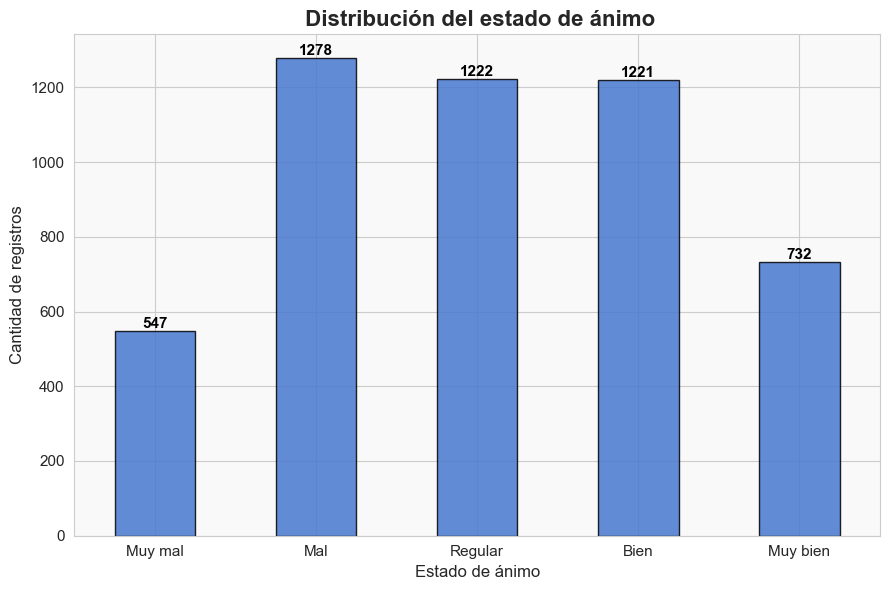

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo moderno
sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(9,6))

# Gráfico de barras estilizado
ax = mood_counts.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title(" Distribución del estado de ánimo", fontsize=16, fontweight="bold")
ax.set_xlabel("Estado de ánimo", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold", color="black")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


In [59]:
emotional_by_risk = (
    df.groupby(
        "risk_level",
        observed=True,
    )[[
        "stress_level",
        "energy_level",
        "sleep_quality",
        "emotional_score",
    ]]
    .mean()
    .reindex(["low", "medium", "high"])
    .round(2)
)

emotional_by_risk

,stress_level,energy_level,sleep_quality,emotional_score
risk_level,,,,
low,1.99,6.50,7.77,76.33
medium,4.60,3.44,6.02,46.79
high,6.45,1.72,4.57,27.06


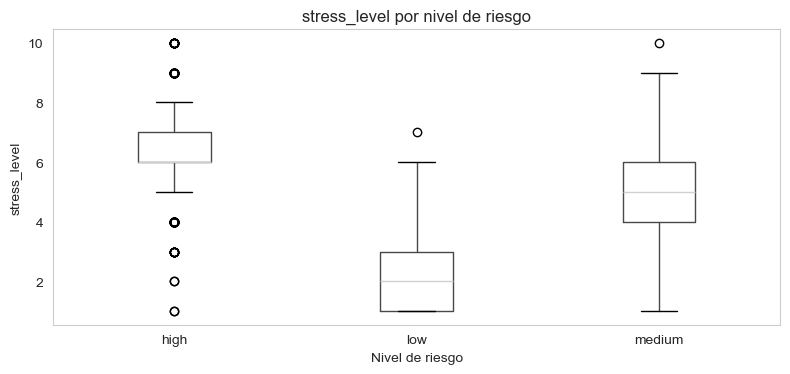

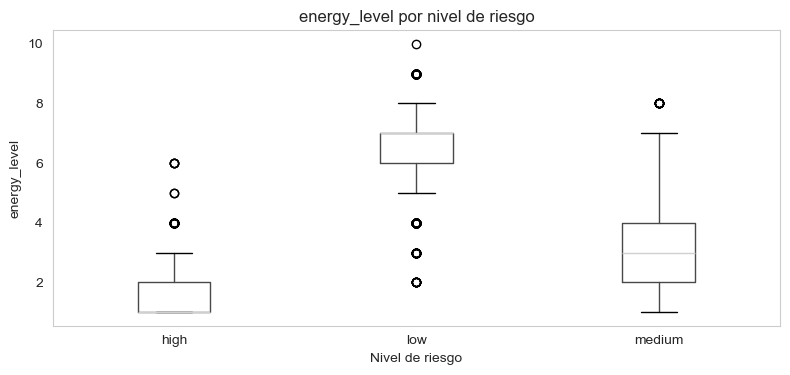

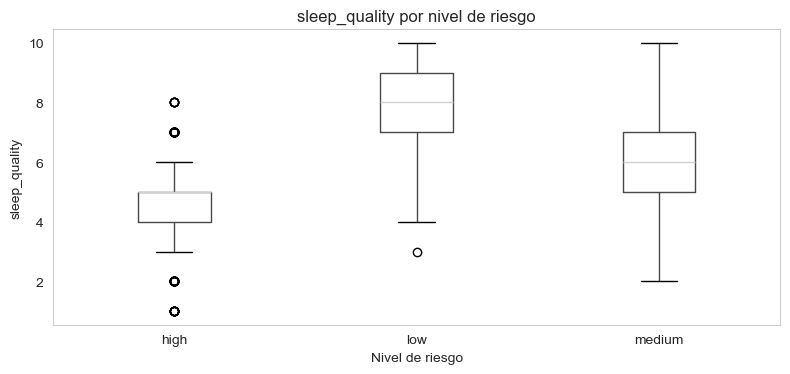

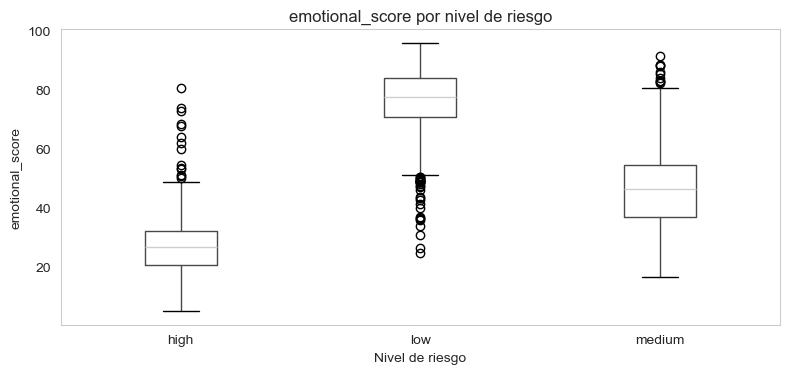

In [62]:
emotional_plot_columns = [
    "stress_level",
    "energy_level",
    "sleep_quality",
    "emotional_score",
]

for column in emotional_plot_columns:
    ax = df.boxplot(
        column=column,
        by="risk_level",
        figsize=(8, 4),
        grid=False,
    )

    plt.title(f"{column} por nivel de riesgo")
    plt.suptitle("")
    plt.xlabel("Nivel de riesgo")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

### Interpretación emocional

Se espera que los registros clasificados como riesgo alto presenten:

- Mayor nivel de estrés.
- Menor nivel de energía.
- Menor calidad del sueño.
- Menor puntaje emocional.
- Mayor presencia de estados de ánimo `Mal` o `Muy mal`.

Estas relaciones fueron incorporadas en la simulación, pero conservan variación para evitar una separación totalmente artificial.

## 14. Análisis de síntomas y signos físicos

Se analizarán las siguientes variables:

- Dolor.
- Temperatura corporal.
- Presión sistólica.
- Presión diastólica.
- Glucosa.
- Frecuencia cardiaca.
- Peso e índice de masa corporal.

In [63]:
physical_summary = (
    df[physical_columns + ["weight_kg", "bmi"]]
    .describe()
    .T[
        ["min", "25%", "50%", "mean", "75%", "max", "std"]
    ]
    .round(2)
)

physical_summary

,min,25%,50%,mean,75%,max,std
pain,0.00,1.00,3.00,2.93,5.00,10.00,2.28
temperature_c,35.40,36.50,36.70,36.72,37.00,38.40,0.36
systolic_mmhg,82.00,112.00,119.00,118.88,126.00,156.00,10.49
diastolic_mmhg,50.00,69.00,74.00,73.93,79.00,98.00,7.16
glucose_mg_dl,50.00,80.00,91.00,90.95,101.00,147.00,15.61
heart_rate_bpm,44.00,74.00,82.00,81.49,89.00,155.00,11.12
weight_kg,40.00,58.20,70.80,72.14,83.60,134.50,18.61
bmi,16.16,21.83,25.29,25.88,29.40,44.33,5.40


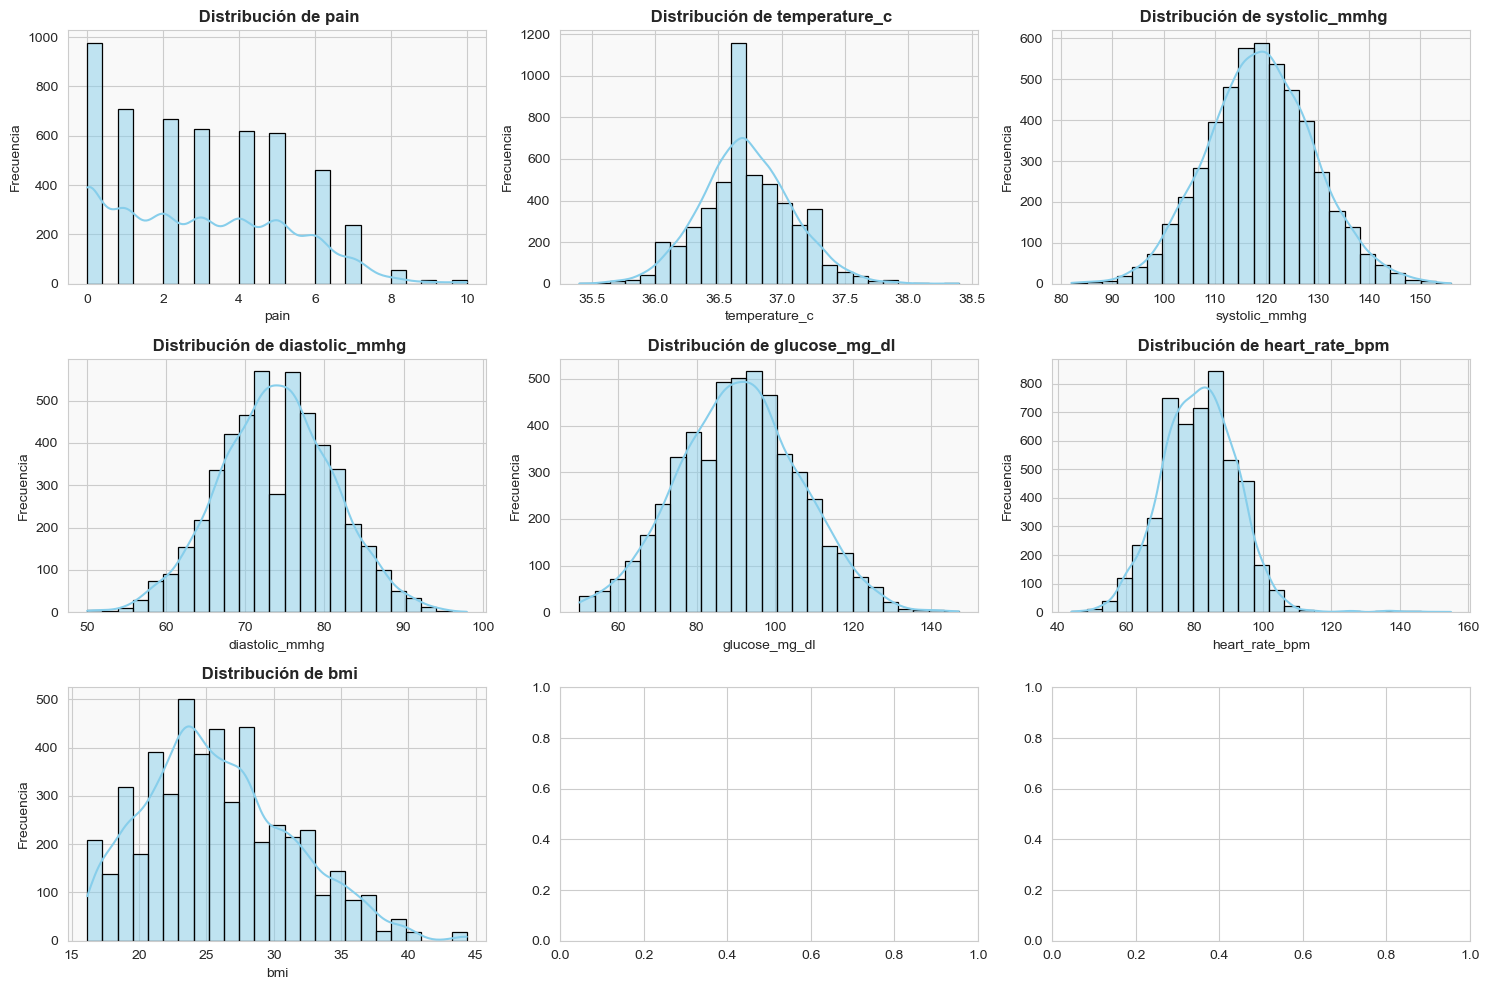

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("pastel")

physical_plot_columns = [
    "pain",
    "temperature_c",
    "systolic_mmhg",
    "diastolic_mmhg",
    "glucose_mg_dl",
    "heart_rate_bpm",
    "bmi",
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,10))
axes = axes.flatten()

for i, column in enumerate(physical_plot_columns):
    sns.histplot(df[column], bins=25, kde=True, ax=axes[i], color="skyblue", edgecolor="black")
    axes[i].set_title(f" Distribución de {column}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].set_facecolor("#f9f9f9")

# Ajustar márgenes
plt.tight_layout()
plt.show()


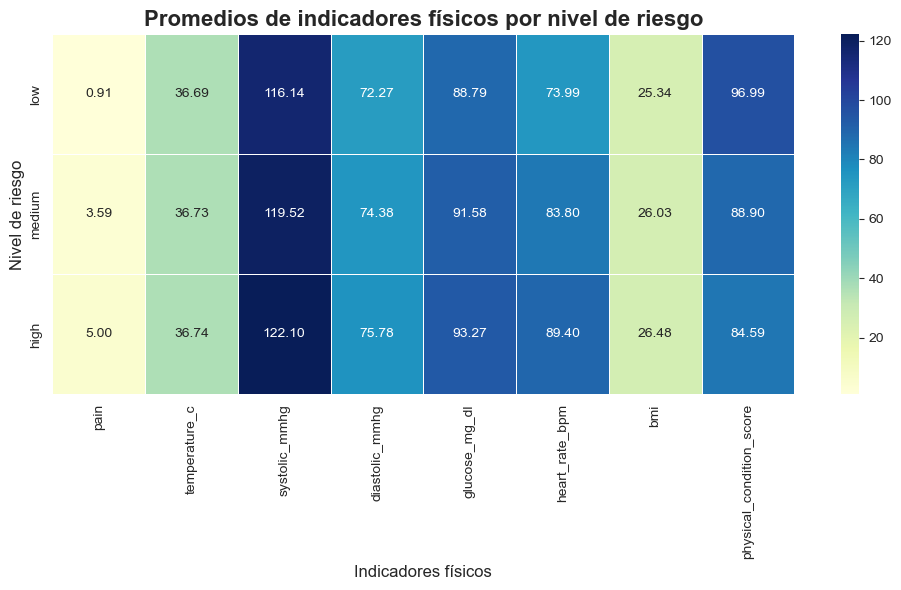

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    physical_by_risk,
    annot=True,        # muestra los valores
    cmap="YlGnBu",     # paleta de colores
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Promedios de indicadores físicos por nivel de riesgo", fontsize=16, fontweight="bold")
plt.xlabel("Indicadores físicos", fontsize=12)
plt.ylabel("Nivel de riesgo", fontsize=12)

plt.tight_layout()
plt.show()


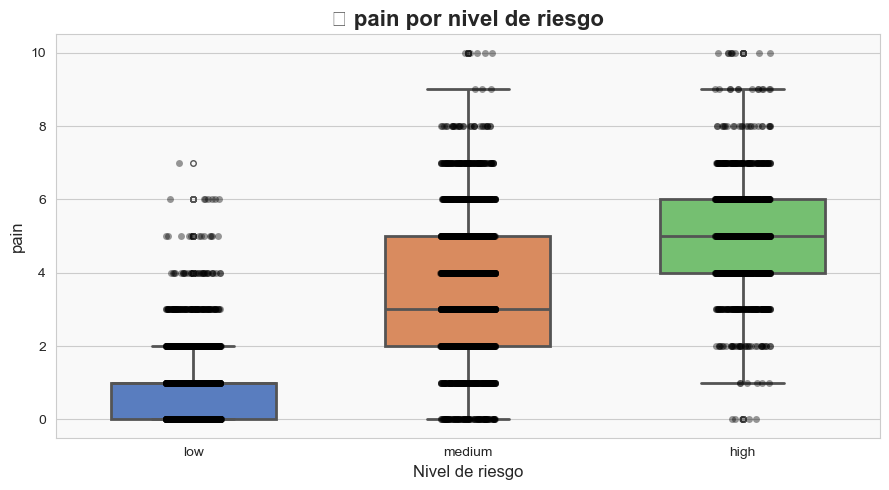

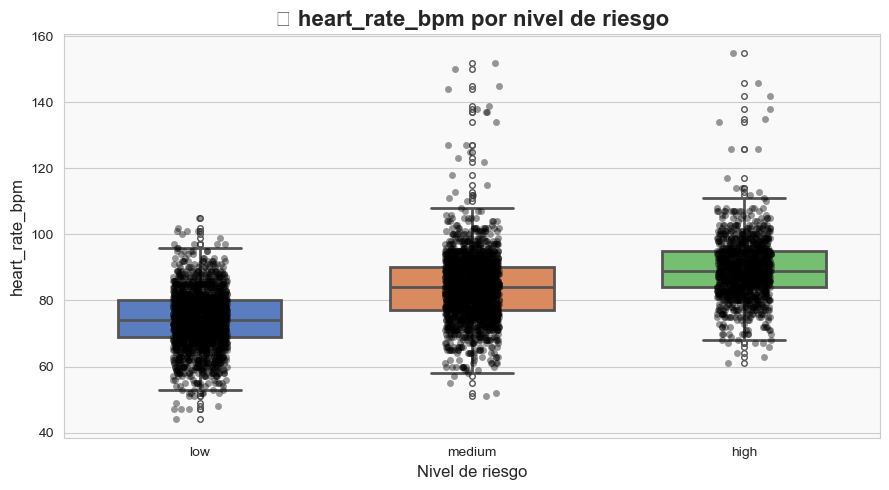

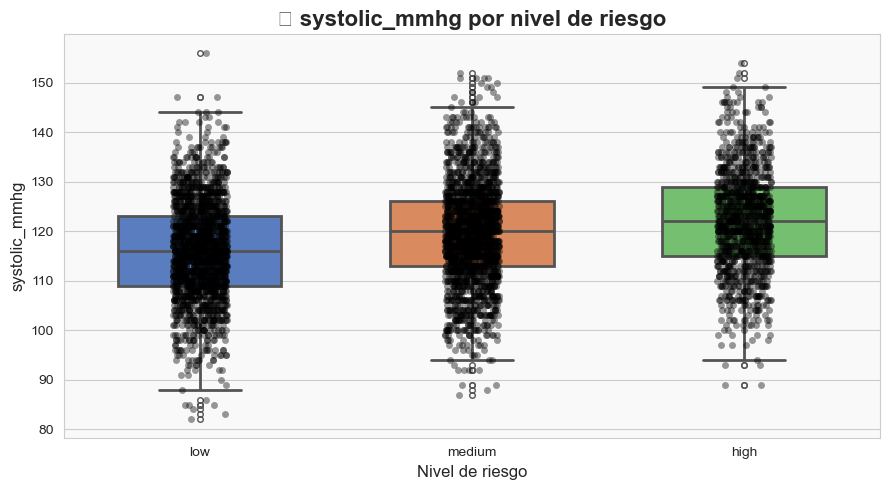

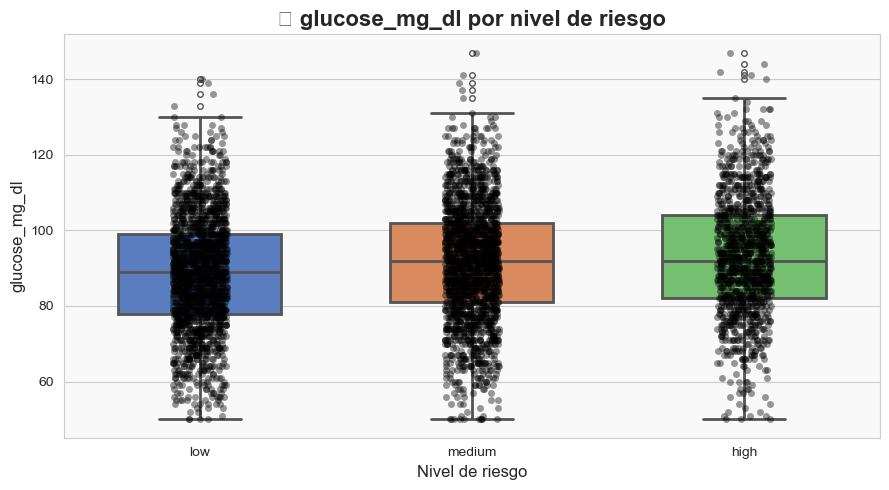

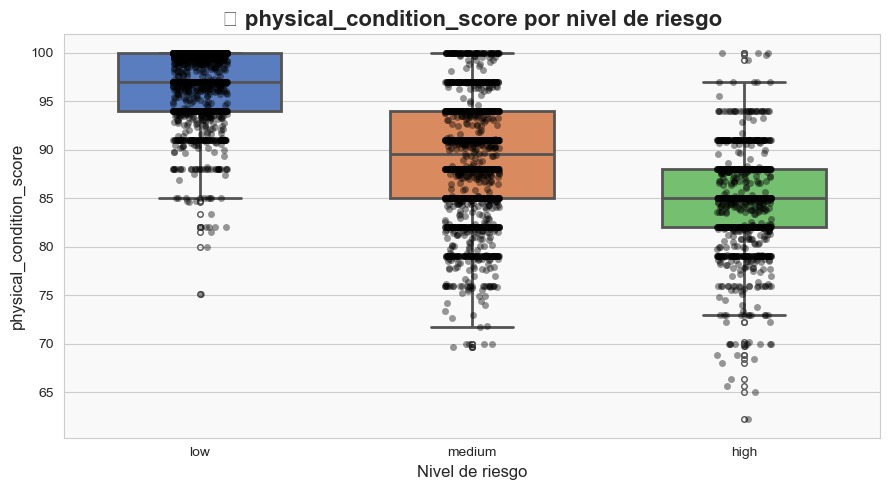

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

comparison_columns = [
    "pain",
    "heart_rate_bpm",
    "systolic_mmhg",
    "glucose_mg_dl",
    "physical_condition_score",
]

for column in comparison_columns:
    plt.figure(figsize=(9,5))
    
    # Boxplot estilizado
    sns.boxplot(
        data=df,
        x="risk_level",
        y=column,
        palette="muted",
        width=0.6,
        linewidth=2,
        fliersize=4
    )
    
    # Overlay con puntos individuales (para ver dispersión real)
    sns.stripplot(
        data=df,
        x="risk_level",
        y=column,
        color="black",
        alpha=0.4,
        jitter=True
    )
    
    # Títulos y etiquetas llamativas
    plt.title(f"✨ {column} por nivel de riesgo", fontsize=16, fontweight="bold")
    plt.xlabel("Nivel de riesgo", fontsize=12)
    plt.ylabel(column, fontsize=12)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


### Interpretación física

Se espera observar que el riesgo alto presenta, en promedio:

- Mayor nivel de dolor.
- Mayor variabilidad en frecuencia cardiaca.
- Valores menos favorables en algunos signos físicos.
- Menor `physical_condition_score`.

No todos los registros con valores físicos elevados deberán clasificarse automáticamente como riesgo alto, ya que la etiqueta se construyó mediante una combinación de factores.

## 15. Análisis de correlaciones

La matriz de correlación permitirá identificar relaciones lineales entre las variables numéricas.

Este análisis ayudará a:

- Detectar variables relacionadas.
- Identificar posibles características redundantes.
- Comprender la relación con `wellbeing_score`
- Revisar las posibles señales de fuga de información
- Seleccionar variables para los modelos.

In [76]:
correlation_excluded_columns = [
    "risk_factors_count",
    "sleep_score",
    "activity_score",
    "nutrition_score",
    "emotional_score",
    "physical_condition_score",
    "wellbeing_score",
]

base_numeric_features = [
    column
    for column in numeric_columns
    if column not in correlation_excluded_columns
]

base_correlation_matrix = (
    df[base_numeric_features]
    .corr()
    .round(2)
)

base_correlation_matrix

,age,height_cm,weight_profile_kg,weight_kg,bmi,water_glasses,water_liters,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,stress_level,energy_level,sleep_quality
age,1.00,-0.04,0.05,0.05,0.09,0.01,0.01,0.02,0.01,-0.02,0.01,-0.04,0.01,0.20,0.11,0.14,-0.02,-0.00,0.02,0.01
height_cm,-0.04,1.00,0.60,0.60,0.13,-0.04,-0.04,-0.05,-0.06,-0.02,-0.02,0.08,0.01,-0.02,-0.00,0.08,0.04,0.05,-0.06,-0.06
weight_profile_kg,0.05,0.60,1.00,1.00,0.86,-0.08,-0.08,-0.08,-0.11,-0.07,-0.06,0.08,0.01,0.03,0.03,0.20,0.06,0.10,-0.10,-0.11
weight_kg,0.05,0.60,1.00,1.00,0.87,-0.08,-0.08,-0.08,-0.11,-0.07,-0.06,0.09,0.01,0.03,0.03,0.20,0.06,0.10,-0.10,-0.11
bmi,0.09,0.13,0.86,0.87,1.00,-0.06,-0.06,-0.06,-0.08,-0.07,-0.05,0.04,0.00,0.04,0.03,0.18,0.04,0.07,-0.08,-0.08
water_glasses,0.01,-0.04,-0.08,-0.08,-0.06,1.00,1.00,0.51,0.49,0.42,0.32,-0.57,-0.05,-0.17,-0.16,-0.09,-0.41,-0.61,0.63,0.51
water_liters,0.01,-0.04,-0.08,-0.08,-0.06,1.00,1.00,0.51,0.49,0.42,0.32,-0.57,-0.05,-0.17,-0.16,-0.09,-0.41,-0.61,0.63,0.51
exercise_minutes,0.02,-0.05,-0.08,-0.08,-0.06,0.51,0.51,1.00,0.48,0.39,0.31,-0.57,-0.04,-0.15,-0.17,-0.12,-0.47,-0.64,0.67,0.49
sleep_hours,0.01,-0.06,-0.11,-0.11,-0.08,0.49,0.49,0.48,1.00,0.41,0.33,-0.60,-0.03,-0.19,-0.16,-0.06,-0.45,-0.73,0.71,0.72
healthy_meals_count,-0.02,-0.02,-0.07,-0.07,-0.07,0.42,0.42,0.39,0.41,1.00,0.27,-0.42,-0.02,-0.13,-0.13,-0.06,-0.33,-0.51,0.52,0.43


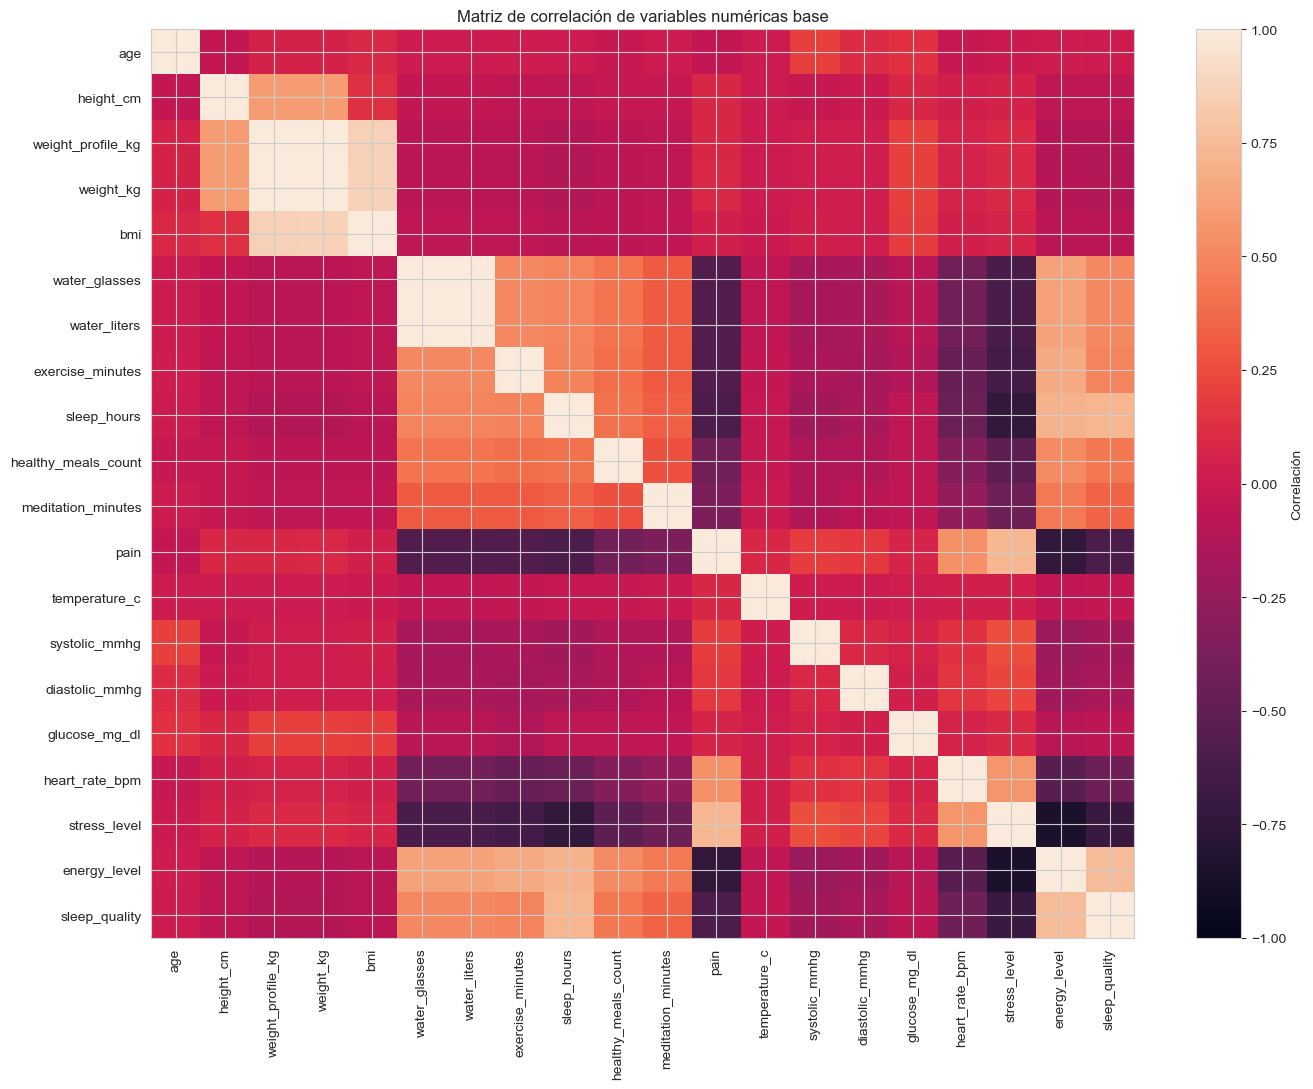

In [77]:
fig, ax = plt.subplots(figsize=(14, 11))

correlation_image = ax.imshow(
    base_correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(base_correlation_matrix.columns))
)
ax.set_yticks(
    range(len(base_correlation_matrix.index))
)

ax.set_xticklabels(
    base_correlation_matrix.columns,
    rotation=90,
)
ax.set_yticklabels(
    base_correlation_matrix.index,
)

ax.set_title(
    "Matriz de correlación de variables numéricas base"
)

fig.colorbar(
    correlation_image,
    ax=ax,
    label="Correlación",
)

plt.tight_layout()
plt.show()

In [78]:
correlation_pairs = (
    base_correlation_matrix
    .where(
        np.triu(
            np.ones(base_correlation_matrix.shape),
            k=1,
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlacion",
]

strongest_correlations = (
    correlation_pairs
    .assign(
        correlacion_absoluta=lambda data: (
            data["correlacion"].abs()
        )
    )
    .sort_values(
        "correlacion_absoluta",
        ascending=False,
    )
    .head(15)
)

strongest_correlations

,variable_1,variable_2,correlacion,correlacion_absoluta
85,water_glasses,water_liters,1.00,1.00
37,weight_profile_kg,weight_kg,1.00,1.00
54,weight_kg,bmi,0.87,0.87
38,weight_profile_kg,bmi,0.86,0.86
187,stress_level,energy_level,-0.85,0.85
189,energy_level,sleep_quality,0.75,0.75
160,pain,energy_level,-0.73,0.73
159,pain,stress_level,0.73,0.73
132,sleep_hours,stress_level,-0.73,0.73
134,sleep_hours,sleep_quality,0.72,0.72


### Interpretación de correlaciones

Las correlaciones más altas deberán analizarse considerando las reglas utilizadas durante la simulación.

Una correlación elevada no demuestra causalidad.

También deberá revisarse si existen variables que contienen información derivada o redundante. Por ejemplo:

- `weight_kg`, `height_cm` y `bmi`.
- `water_glasses` y `water_liters`.
- `sleep_hours` y `sleep_quality`.
- `stress_level`, `energy_level` y `mood`.

Para el entrenamiento no deberán utilizarse simultáneamente variables redundantes sin revisar previamente su efecto.

## Correlación con el bienestar


In [79]:
wellbeing_correlations = (
    df[numeric_columns]
    .corr()["wellbeing_score"]
    .drop("wellbeing_score")
    .sort_values()
)

wellbeing_correlations

risk_factors_count         -0.88
stress_level               -0.87
pain                       -0.76
heart_rate_bpm             -0.57
systolic_mmhg              -0.23
diastolic_mmhg             -0.21
weight_kg                  -0.12
weight_profile_kg          -0.11
glucose_mg_dl              -0.11
bmi                        -0.09
height_cm                  -0.06
temperature_c              -0.06
age                         0.01
meditation_minutes          0.42
healthy_meals_count         0.60
water_liters                0.69
water_glasses               0.69
physical_condition_score    0.75
nutrition_score             0.75
sleep_hours                 0.78
sleep_quality               0.78
exercise_minutes            0.81
activity_score              0.82
sleep_score                 0.83
energy_level                0.89
emotional_score             0.93
Name: wellbeing_score, dtype: float64

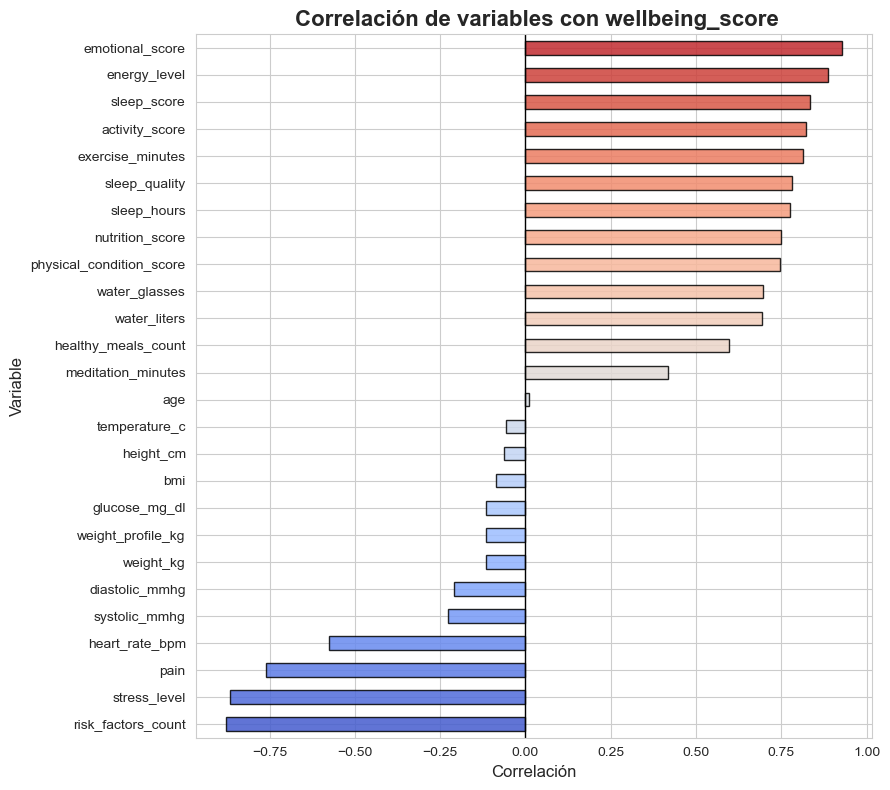

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(9,8))

ax = wellbeing_correlations.plot(
    kind="barh",
    color=sns.color_palette("coolwarm", len(wellbeing_correlations)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title(" Correlación de variables con wellbeing_score", fontsize=16, fontweight="bold")
ax.set_xlabel("Correlación", fontsize=12)
ax.set_ylabel("Variable", fontsize=12)

# Línea vertical en 0 para referencia
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


### Advertencia sobre variables derivadas

Los puntajes:

- `sleep_score`
- `activity_score`
- `nutrition_score`
- `emotional_score`
- `physical_condition_score`

participaron directamente en la construcción de `wellbeing_score`.

Por ello, es esperable que presenten correlaciones altas.

Antes de entrenar el modelo de regresión deberán evaluarse dos enfoques:

1. Predecir `wellbeing_score` utilizando únicamente variables originales.
2. Predecirlo utilizando variables derivadas.

El primer enfoque será más útil para comprobar si el modelo aprende relaciones reales y no solamente la fórmula utilizada para crear el objetivo.

## Relación entre variables seleccionadas

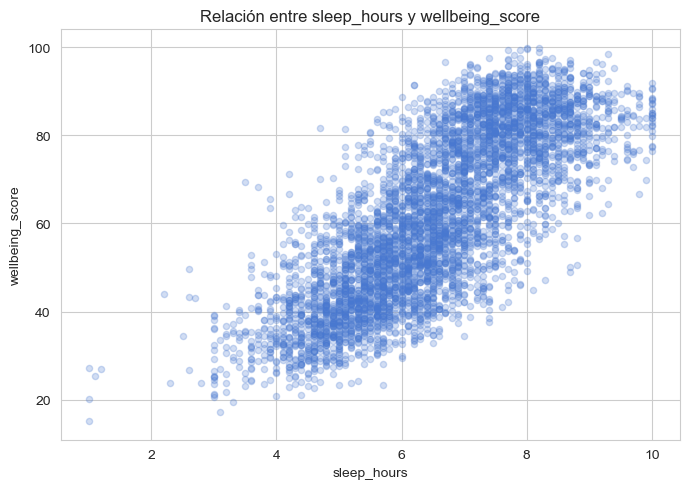

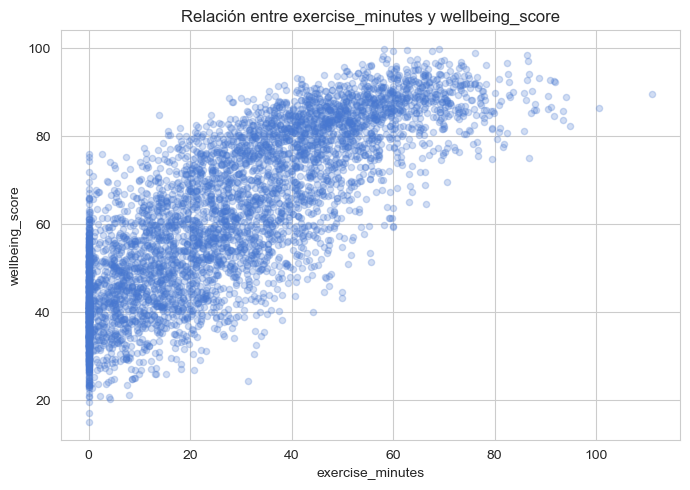

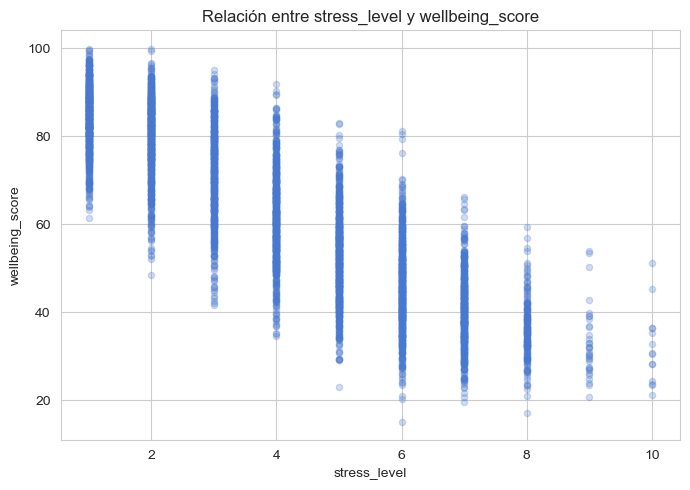

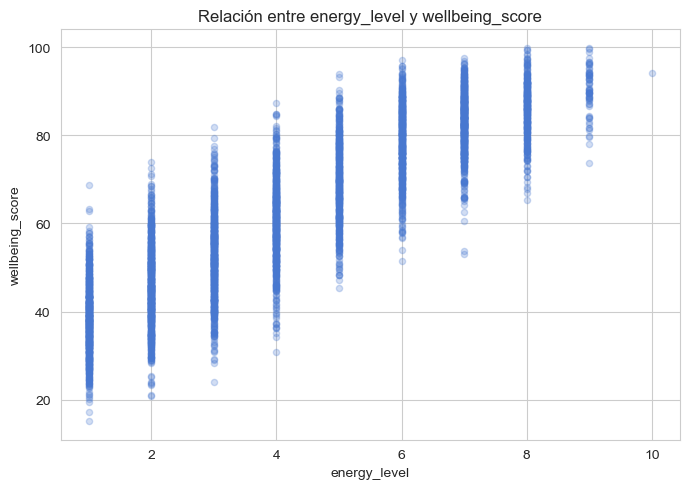

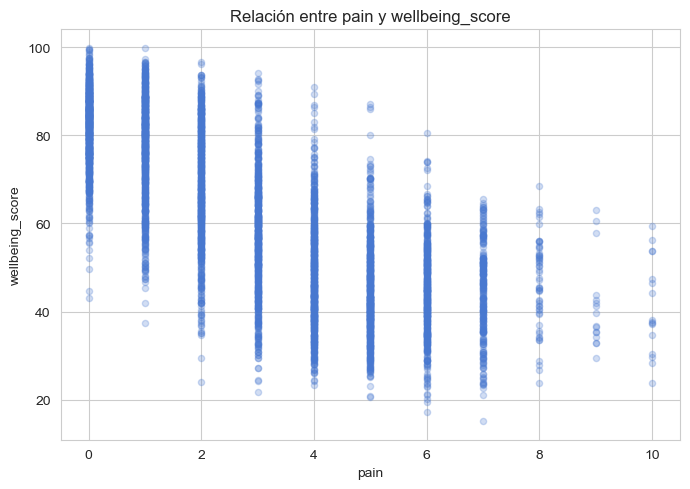

In [85]:
scatter_pairs = [
    ("sleep_hours", "wellbeing_score"),
    ("exercise_minutes", "wellbeing_score"),
    ("stress_level", "wellbeing_score"),
    ("energy_level", "wellbeing_score"),
    ("pain", "wellbeing_score"),
]

for x_column, y_column in scatter_pairs:
    ax = df.plot.scatter(
        x=x_column,
        y=y_column,
        figsize=(7, 5),
        alpha=0.25,
    )

    ax.set_title(
        f"Relación entre {x_column} y {y_column}"
    )
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)

    plt.tight_layout()
    plt.show()

## 16. Comportamiento temporal

Se analizarán los promedios diarios para identificar cambios generales durante el periodo simulado.

Las tendencias globales no representan el comportamiento individual de todos los usuarios.

In [86]:
daily_summary = (
    df.groupby("log_date")
    .agg(
        wellbeing_score=("wellbeing_score", "mean"),
        sleep_hours=("sleep_hours", "mean"),
        exercise_minutes=("exercise_minutes", "mean"),
        stress_level=("stress_level", "mean"),
        energy_level=("energy_level", "mean"),
        pain=("pain", "mean"),
        records=("record_id", "count"),
    )
    .sort_index()
)

daily_summary.head()

,wellbeing_score,sleep_hours,exercise_minutes,stress_level,energy_level,pain,records
log_date,,,,,,,
2026-04-01,63.36,6.61,31.12,4.07,4.65,3.11,46
2026-04-02,63.05,6.78,27.39,4.02,4.40,2.90,50
2026-04-03,59.54,6.53,25.74,4.76,4.15,2.96,55
2026-04-04,60.82,6.65,26.21,4.27,4.12,2.83,52
2026-04-05,61.49,6.61,25.60,4.27,4.30,2.70,60


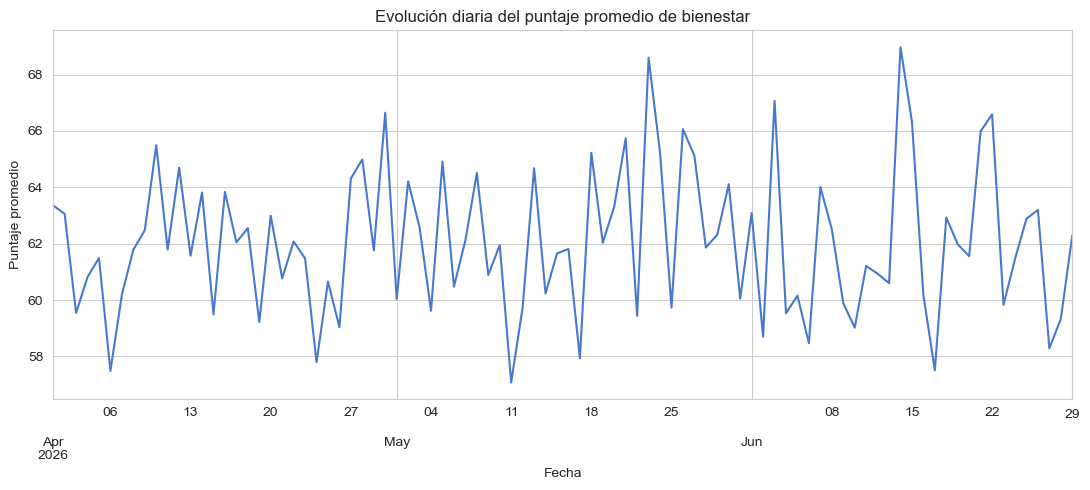

In [89]:
ax = daily_summary["wellbeing_score"].plot(
    figsize=(11, 5),
)

ax.set_title(
    "Evolución diaria del puntaje promedio de bienestar"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Puntaje promedio")

plt.tight_layout()
plt.show()

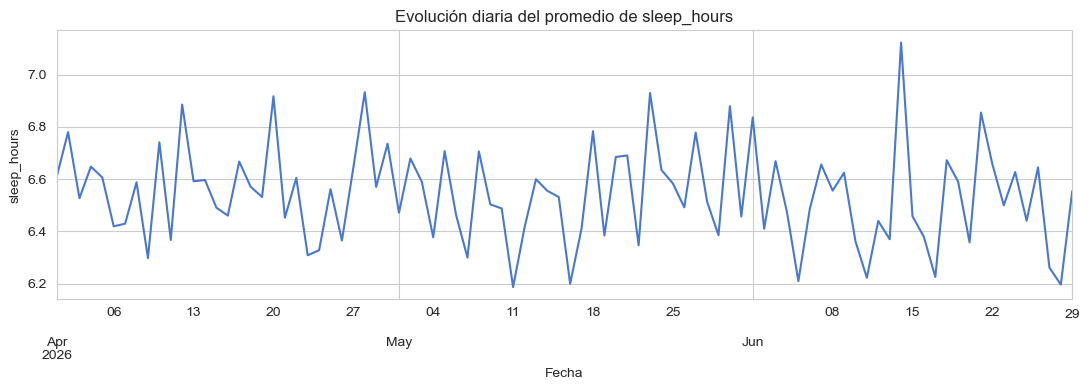

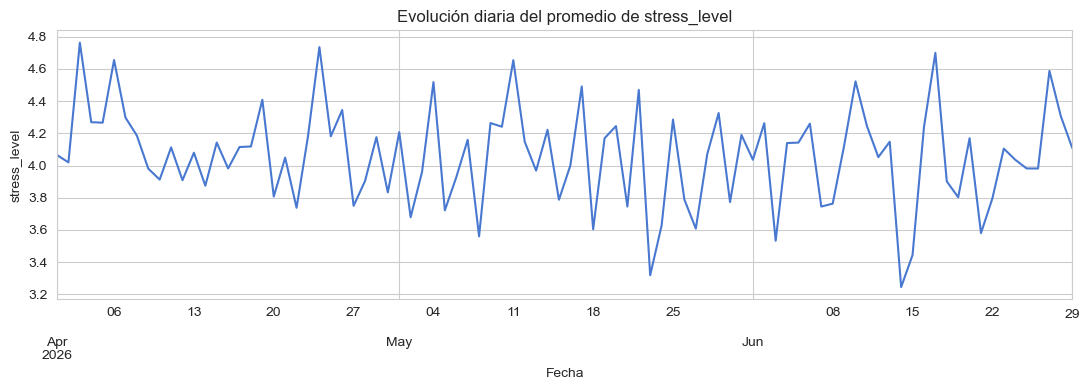

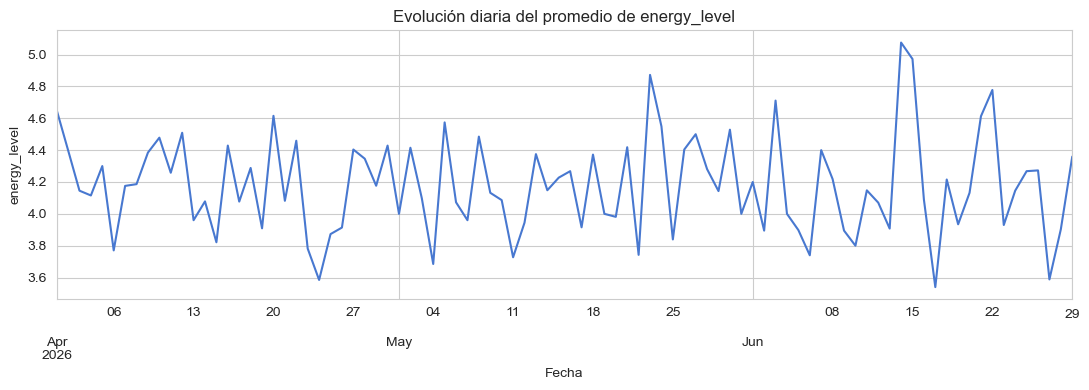

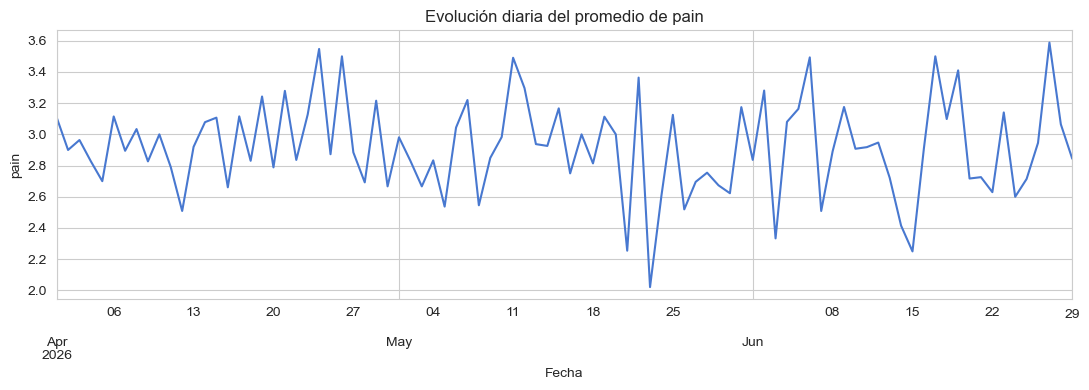

In [90]:
temporal_columns = [
    "sleep_hours",
    "stress_level",
    "energy_level",
    "pain",
]

for column in temporal_columns:
    ax = daily_summary[column].plot(
        figsize=(11, 4),
    )

    ax.set_title(
        f"Evolución diaria del promedio de {column}"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel(column)

    plt.tight_layout()
    plt.show()

In [91]:
daily_risk_distribution = (
    pd.crosstab(
        df["log_date"],
        df["risk_level"],
        normalize="index",
    )
    .mul(100)
    .reindex(
        columns=["low", "medium", "high"],
        fill_value=0,
    )
)

daily_risk_distribution.head()

risk_level,low,medium,high
log_date,,,
2026-04-01,43.48,39.13,17.39
2026-04-02,42.00,36.00,22.00
2026-04-03,29.09,41.82,29.09
2026-04-04,32.69,44.23,23.08
2026-04-05,33.33,43.33,23.33


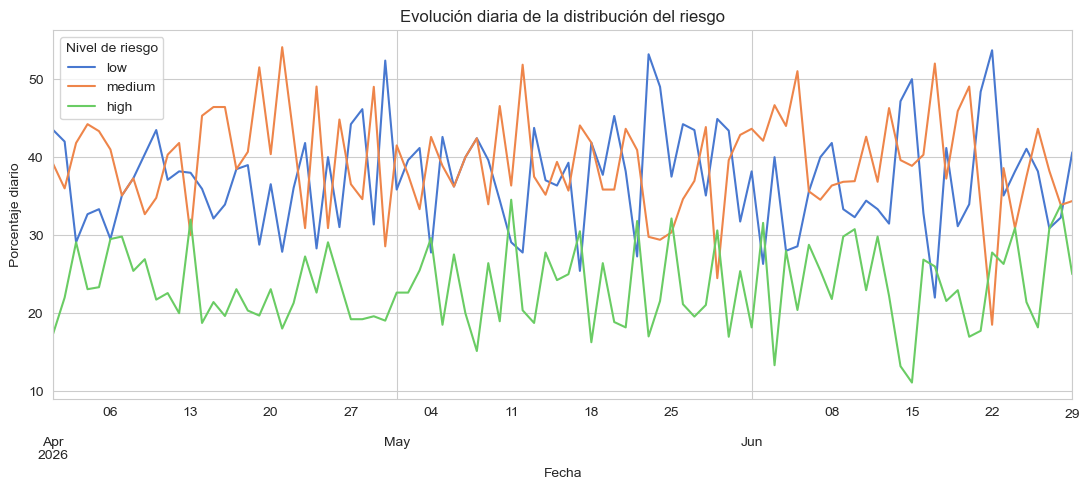

In [92]:
ax = daily_risk_distribution.plot(
    figsize=(11, 5),
)

ax.set_title(
    "Evolución diaria de la distribución del riesgo"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Porcentaje diario")
ax.legend(title="Nivel de riesgo")

plt.tight_layout()
plt.show()

## 17. Anáñisis de anomalías sintéticas

La variable `is_anomaly` identifica registros que fueron modificados intencionalmente durante la simulación para representar cambios poco habituales.

Esta variable se utilizará para evaluar posteriormente los modelos no supervisados, pero no se incluirá como característica durante su entrenamiento.

In [93]:
anomaly_counts = df["is_anomaly"].value_counts()

anomaly_percentages = (
    df["is_anomaly"]
    .value_counts(normalize=True)
    .mul(100)
)

anomaly_summary = pd.DataFrame(
    {
        "registros": anomaly_counts,
        "porcentaje": anomaly_percentages,
    }
)

anomaly_summary

,registros,porcentaje
is_anomaly,,
False,4850,97.00
True,150,3.00


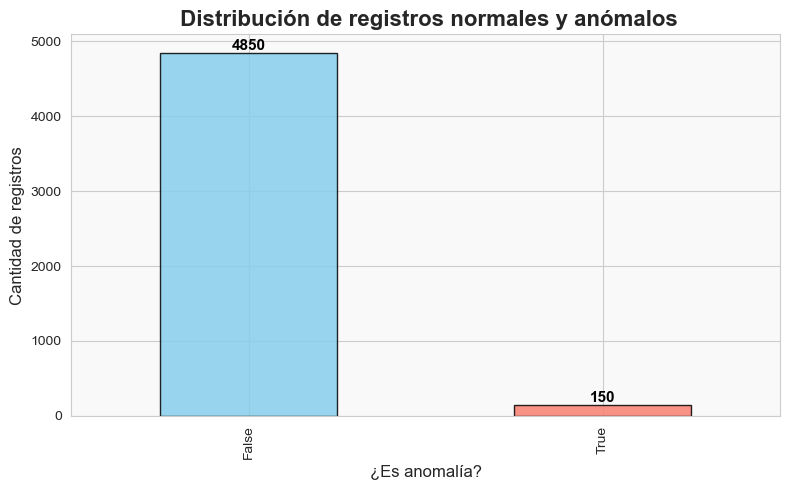

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(8,5))

ax = anomaly_counts.plot(
    kind="bar",
    color=["skyblue","salmon"],  # colores distintos para normal vs anomalía
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title(" Distribución de registros normales y anómalos", fontsize=16, fontweight="bold")
ax.set_xlabel("¿Es anomalía?", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold", color="black")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


In [96]:
anomaly_comparison_columns = [
    "sleep_hours",
    "exercise_minutes",
    "stress_level",
    "energy_level",
    "pain",
    "heart_rate_bpm",
    "wellbeing_score",
]

anomaly_comparison = (
    df.groupby("is_anomaly")[
        anomaly_comparison_columns
    ]
    .mean()
    .round(2)
)

anomaly_comparison

,sleep_hours,exercise_minutes,stress_level,energy_level,pain,heart_rate_bpm,wellbeing_score
is_anomaly,,,,,,,
False,6.56,27.87,4.04,4.18,2.89,81.24,62.19
True,5.67,20.24,5.07,3.65,4.31,89.71,53.38


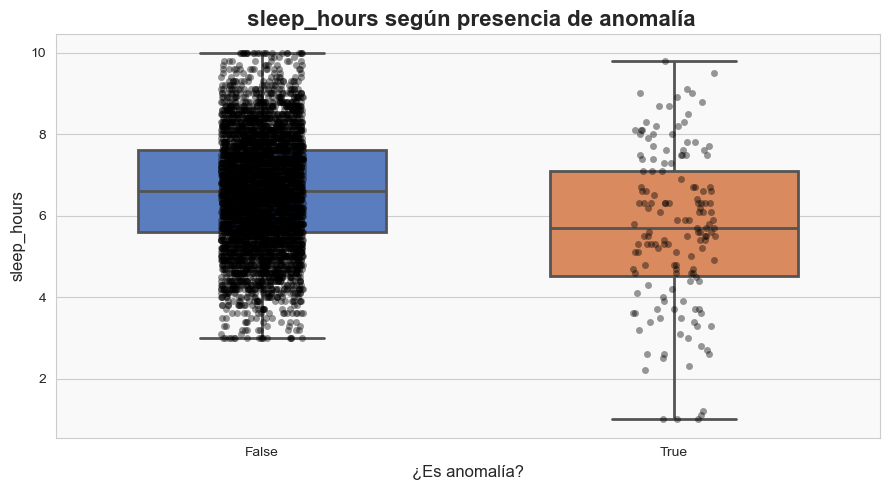

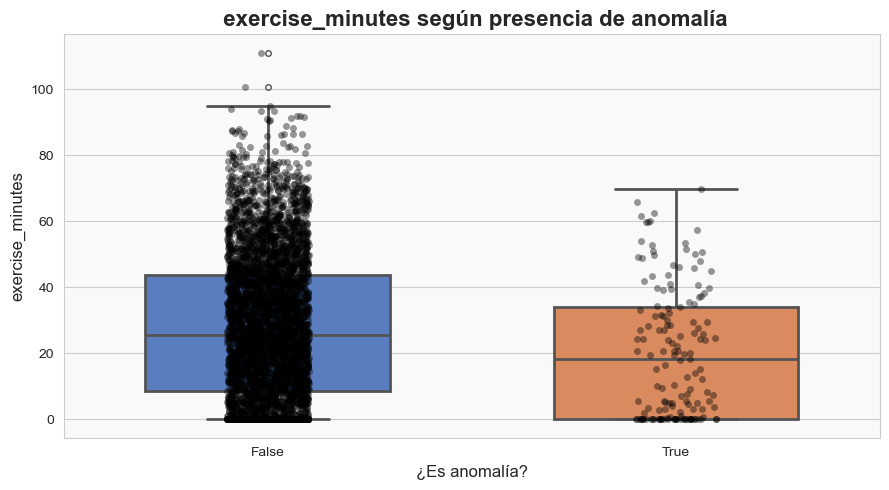

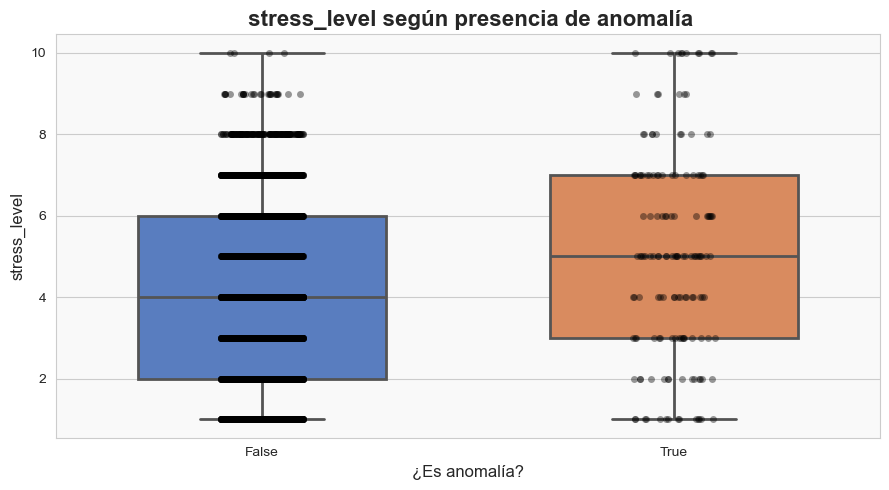

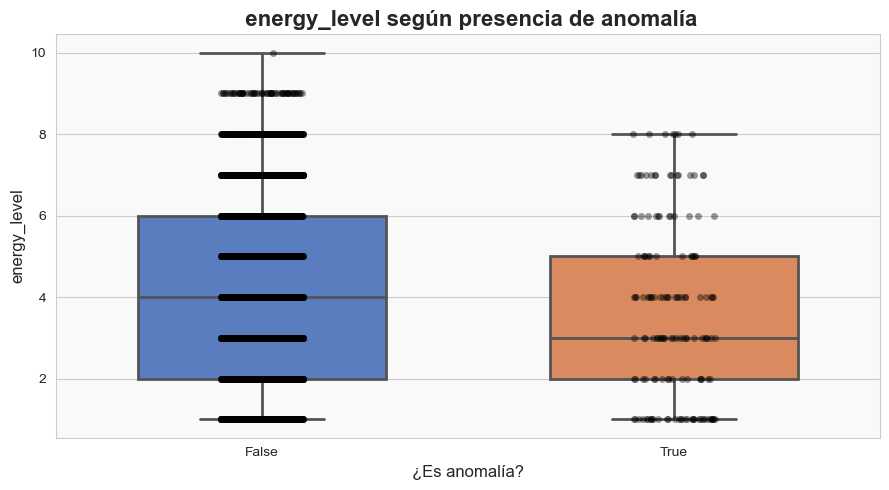

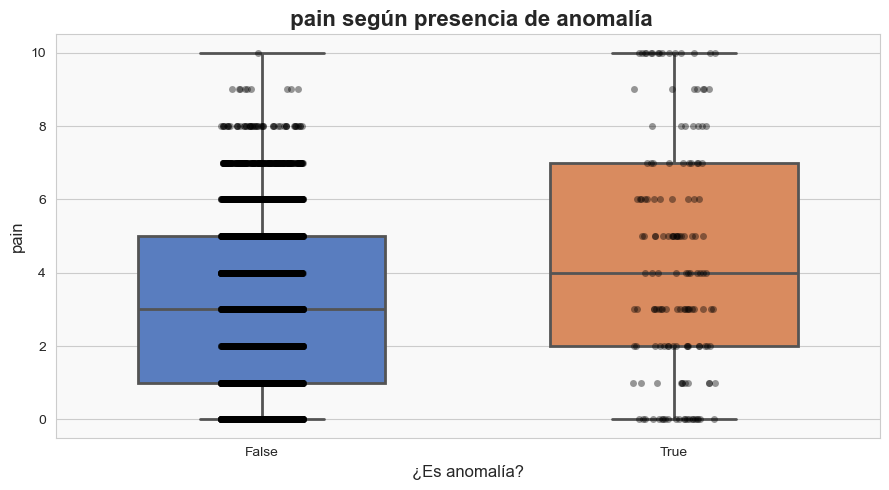

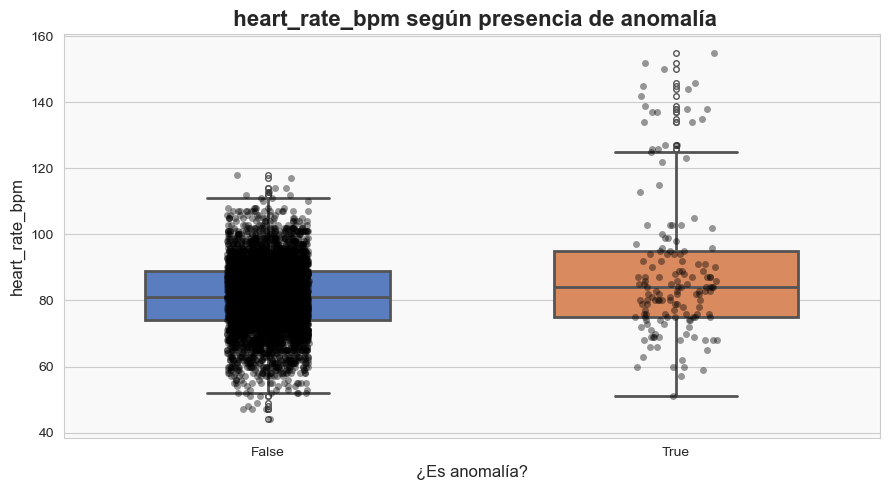

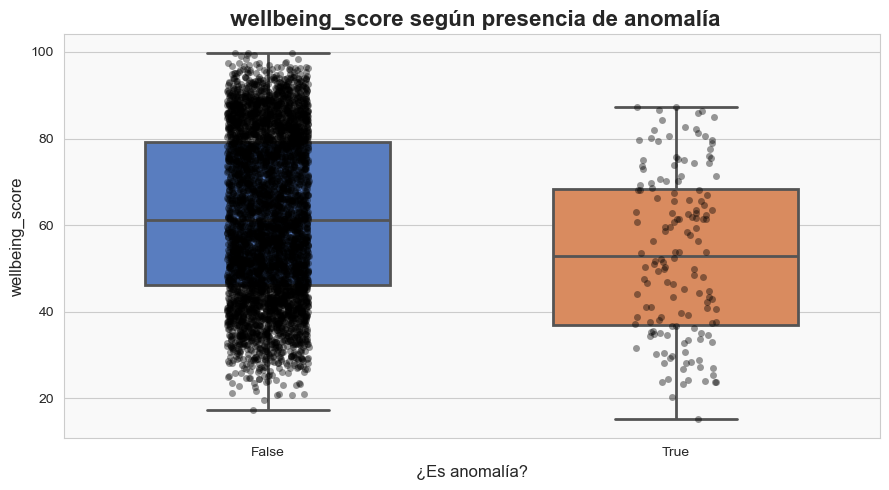

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

for column in anomaly_comparison_columns:
    plt.figure(figsize=(9,5))
    
    # Boxplot estilizado
    sns.boxplot(
        data=df,
        x="is_anomaly",
        y=column,
        palette="muted",
        width=0.6,
        linewidth=2,
        fliersize=4
    )
    
    # Overlay con puntos individuales (para ver dispersión real)
    sns.stripplot(
        data=df,
        x="is_anomaly",
        y=column,
        color="black",
        alpha=0.4,
        jitter=True
    )
    
    # Títulos y etiquetas llamativas
    plt.title(f" {column} según presencia de anomalía", fontsize=16, fontweight="bold")
    plt.xlabel("¿Es anomalía?", fontsize=12)
    plt.ylabel(column, fontsize=12)
    
    # Fondo claro
    plt.gca().set_facecolor("#f9f9f9")
    
    plt.tight_layout()
    plt.show()


## 18. Análisis por perfil de usuario

Durante la simulación se asignaron perfiles base para generar comportamientos diarios con características diferentes.

Los perfiles disponibles son:

- `healthy`
- `irregular`
- `poor_habits`
- `physically_vulnerable`
  
Este campo se utilizará únicamente para analizar cómo fue construido el dataset sintetico.

No deberá utilizarse como característica durante el entrenamiento de los modelos, porque no existirá en los datos reales de Backend.

In [102]:
profile_counts = (
    df["profile_type"]
    .value_counts()
)

profile_percentages = (
    df["profile_type"]
    .value_counts(normalize=True)
    .mul(100)
)

profile_summary = pd.DataFrame(
    {
        "registros": profile_counts,
        "porcentaje": profile_percentages,
    }
)

profile_summary

,registros,porcentaje
profile_type,,
healthy,1776,35.52
poor_habits,1280,25.60
irregular,1229,24.58
physically_vulnerable,715,14.30


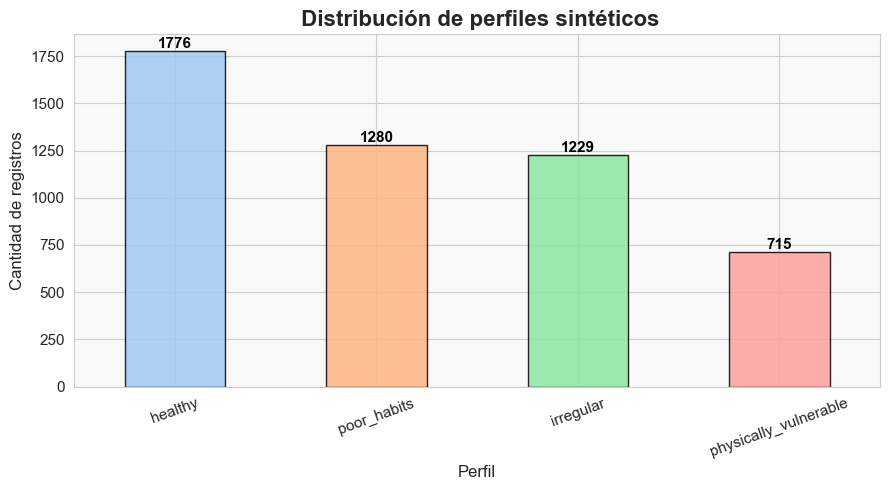

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("pastel")

plt.figure(figsize=(9,5))

ax = profile_counts.plot(
    kind="bar",
    color=sns.color_palette("pastel", len(profile_counts)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title(" Distribución de perfiles sintéticos", fontsize=16, fontweight="bold")
ax.set_xlabel("Perfil", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=20, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold", color="black")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


In [105]:
profile_comparison_columns = [
    "sleep_hours",
    "exercise_minutes",
    "water_glasses",
    "healthy_meals_count",
    "meditation_minutes",
    "stress_level",
    "energy_level",
    "pain",
    "wellbeing_score",
]

profile_comparison = (
    df.groupby(
        "profile_type",
        observed=True,
    )[profile_comparison_columns]
    .mean()
    .round(2)
)

profile_comparison

,sleep_hours,exercise_minutes,water_glasses,healthy_meals_count,meditation_minutes,stress_level,energy_level,pain,wellbeing_score
profile_type,,,,,,,,,
healthy,7.74,45.85,8.51,2.99,15.39,1.82,6.71,0.75,82.00
irregular,6.44,25.90,6.30,1.98,8.79,4.09,3.97,2.51,61.89
physically_vulnerable,5.96,15.27,5.14,2.04,6.98,5.32,2.65,5.85,50.53
poor_habits,5.29,10.97,3.65,1.03,5.07,6.48,1.67,4.74,40.47


In [106]:
profile_risk_distribution = (
    pd.crosstab(
        df["profile_type"],
        df["risk_level"],
        normalize="index",
    )
    .mul(100)
    .reindex(
        columns=["low", "medium", "high"],
        fill_value=0,
    )
    .round(2)
)

profile_risk_distribution

risk_level,low,medium,high
profile_type,,,
healthy,89.81,9.91,0.28
irregular,18.96,76.97,4.07
physically_vulnerable,2.38,70.35,27.27
poor_habits,0.31,26.95,72.73


<Figure size 1000x500 with 0 Axes>

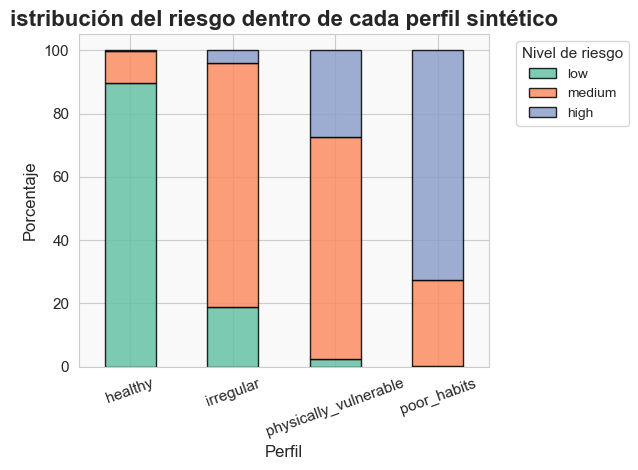

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("muted")

plt.figure(figsize=(10,5))

ax = profile_risk_distribution.plot(
    kind="bar",
    stacked=True,
    color=sns.color_palette("Set2", len(profile_risk_distribution.columns)),
    edgecolor="black",
    alpha=0.85
)

# Títulos y etiquetas llamativas
ax.set_title("istribución del riesgo dentro de cada perfil sintético", fontsize=16, fontweight="bold")
ax.set_xlabel("Perfil", fontsize=12)
ax.set_ylabel("Porcentaje", fontsize=12)

# Ajuste de ticks
ax.tick_params(axis="x", rotation=20, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Leyenda estilizada
ax.legend(title="Nivel de riesgo", fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc="upper left")

# Fondo claro
plt.gca().set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


### Interpretación de perfiles

Los perfiles permiten comprobar que la simulación generó grupos con comportamientos diferentes.

Se espera que:

- `healthy` presente mayor bienestar y mayor proporción de riesgo bajo.
- `irregular` presente resultados intermedios.
- `poor_habits` presente menor bienestar y mayor proporción de riesgo medio o alto.
- `physically_vulnerable` presente mayor afectación en síntomas y condición física.

`profile_type` deberá excluirse del entrenamiento, ya que es una variable creada exclusivamente para controlar la simulación.

## 19. Revisión de fuga de información

La fuga de información ocurre cuando el modelo recibe variables que contienen directa o indirectamente información sobre el objetivo que no estaría disponible durante una predicción real.

En este dataset existen variables derivadas que participaron en la generación de los objetivos.

Por esta razón, deberán excluirse o evaluarse cuidadosamente antes del entrenamiento.

In [109]:
classification_target = "risk_level"
regression_target = "wellbeing_score"

technical_columns = [
    "record_id",
    "user_id",
    "log_date",
]

simulation_only_columns = [
    "profile_type",
    "is_anomaly",
]

redundant_columns = [
    "water_liters",
    "weight_profile_kg",
]

derived_score_columns = [
    "sleep_score",
    "activity_score",
    "nutrition_score",
    "emotional_score",
    "physical_condition_score",
]

classification_leakage_columns = [
    "wellbeing_score",
    "risk_factors_count",
    *derived_score_columns,
]

regression_leakage_columns = [
    "risk_level",
    "risk_factors_count",
    *derived_score_columns,
]

print("Columnas técnicas:")
print(technical_columns)

print("\nVariables exclusivas de simulación:")
print(simulation_only_columns)

print("\nVariables redundantes:")
print(redundant_columns)

print("\nPosible fuga para clasificación:")
print(classification_leakage_columns)

print("\nPosible fuga para regresión:")
print(regression_leakage_columns)

Columnas técnicas:
['record_id', 'user_id', 'log_date']

Variables exclusivas de simulación:
['profile_type', 'is_anomaly']

Variables redundantes:
['water_liters', 'weight_profile_kg']

Posible fuga para clasificación:
['wellbeing_score', 'risk_factors_count', 'sleep_score', 'activity_score', 'nutrition_score', 'emotional_score', 'physical_condition_score']

Posible fuga para regresión:
['risk_level', 'risk_factors_count', 'sleep_score', 'activity_score', 'nutrition_score', 'emotional_score', 'physical_condition_score']


### Variables que deberán excluirse del clasificador de riesgo

- `record_id`
- `user_id`
- `log_date`
- `profile_type`
- `is_anomaly`
- `risk_factors_count`
- `wellbeing_score`
- Puntajes derivados utilizados para construir `wellbeing_score`
- `water_liters`, porque duplica la información de `water_glasses`
- `weight_profile_kg`, cuando ya se utiliza `weight_kg`

La exclusión de estas columnas evita que el modelo aprenda reglas artificiales o información que no estará disponible durante una inferencia real.

## 20. Selección preliminar de variables para clasificación

El primer clasificador utilizará únicamente variables originales o directamente disponibles en Backend.

La variable objetivo será:

```text
risk_level
```

```python
classification_features = [
    "age",
    "height_cm",
    "weight_kg",
    "bmi",
    "water_glasses",
    "exercise_minutes",
    "sleep_hours",
    "healthy_meals_count",
    "meditation_minutes",
    "pain",
    "temperature_c",
    "systolic_mmhg",
    "diastolic_mmhg",
    "glucose_mg_dl",
    "heart_rate_bpm",
    "mood",
    "stress_level",
    "energy_level",
    "sleep_quality",
]

classification_features

In [111]:
classification_dataset = df[
    classification_features
    + [classification_target]
].copy()

print(
    "Dimensiones del dataset preliminar "
    "de clasificación:"
)
print(classification_dataset.shape)

classification_dataset.head()



Dimensiones del dataset preliminar de clasificación:
(5000, 20)


,age,height_cm,weight_kg,bmi,water_glasses,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,mood,stress_level,energy_level,sleep_quality,risk_level
0,40,164.40,68.40,25.31,10.97,40.60,7.50,2,17.00,1,37.00,118,76,79,67,Bien,2,7,6,low
1,40,164.40,68.50,25.34,6.85,32.60,7.30,4,27.80,0,37.30,109,58,69,87,Bien,1,6,6,low
2,40,164.40,68.70,25.42,8.73,16.40,8.40,2,18.70,1,36.70,108,75,92,94,Bien,1,5,8,medium
3,40,164.40,68.70,25.42,7.96,37.30,8.40,3,21.50,0,37.10,115,65,116,59,Muy bien,1,7,9,low
4,40,164.40,68.70,25.42,8.24,45.10,8.20,4,6.40,0,36.80,115,69,101,86,Bien,2,6,5,low


In [112]:
classification_missing = (
    classification_dataset
    .isna()
    .sum()
    .sort_values(ascending=False)
)

classification_missing

age                    0
height_cm              0
sleep_quality          0
energy_level           0
stress_level           0
mood                   0
heart_rate_bpm         0
glucose_mg_dl          0
diastolic_mmhg         0
systolic_mmhg          0
temperature_c          0
pain                   0
meditation_minutes     0
healthy_meals_count    0
sleep_hours            0
exercise_minutes       0
water_glasses          0
bmi                    0
weight_kg              0
risk_level             0
dtype: int64

## 21. Selección preliminar de variables para regresión

La variable objetivo será:

```text
wellbeing_score
```
Para evitar aprender directamente la fórmula de simulación, el primer enfoque utilizará únicamente variables originales.


In [113]:
regression_features = classification_features.copy()

regression_dataset = df[
    regression_features
    + [regression_target]
].copy()

print(
    "Dimensiones del dataset preliminar "
    "de regresión:"
)
print(regression_dataset.shape)

regression_dataset.head()

Dimensiones del dataset preliminar de regresión:
(5000, 20)


,age,height_cm,weight_kg,bmi,water_glasses,exercise_minutes,sleep_hours,healthy_meals_count,meditation_minutes,pain,temperature_c,systolic_mmhg,diastolic_mmhg,glucose_mg_dl,heart_rate_bpm,mood,stress_level,energy_level,sleep_quality,wellbeing_score
0,40,164.40,68.40,25.31,10.97,40.60,7.50,2,17.00,1,37.00,118,76,79,67,Bien,2,7,6,80.85
1,40,164.40,68.50,25.34,6.85,32.60,7.30,4,27.80,0,37.30,109,58,69,87,Bien,1,6,6,72.73
2,40,164.40,68.70,25.42,8.73,16.40,8.40,2,18.70,1,36.70,108,75,92,94,Bien,1,5,8,69.17
3,40,164.40,68.70,25.42,7.96,37.30,8.40,3,21.50,0,37.10,115,65,116,59,Muy bien,1,7,9,91.34
4,40,164.40,68.70,25.42,8.24,45.10,8.20,4,6.40,0,36.80,115,69,101,86,Bien,2,6,5,76.45


## 22. Revisión de variables redundantes

Antes del entrenamiento se revisarán variables que pueden contener información similar.

Ejemplos:

- `weight_kg`, `height_cm` y `bmi`.
- Presión sistólica y diastólica.
- Horas de sueño y calidad del sueño.
- Estado de ánimo, estrés y energía.

La existencia de correlación no implica que una variable deba eliminarse automáticamente.

La decisión dependerá del algoritmo, la interpretabilidad y el rendimiento obtenido.

In [114]:
feature_correlation_matrix = (
    df[
        [
            column
            for column in classification_features
            if column != "mood"
        ]
    ]
    .corr()
)

high_correlation_pairs = (
    feature_correlation_matrix
    .where(
        np.triu(
            np.ones(feature_correlation_matrix.shape),
            k=1,
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlacion",
]

high_correlation_pairs = (
    high_correlation_pairs
    .assign(
        correlacion_absoluta=lambda data: (
            data["correlacion"].abs()
        )
    )
    .query("correlacion_absoluta >= 0.70")
    .sort_values(
        "correlacion_absoluta",
        ascending=False,
    )
)

high_correlation_pairs

,variable_1,variable_2,correlacion,correlacion_absoluta
33,weight_kg,bmi,0.87,0.87
150,stress_level,energy_level,-0.85,0.85
152,energy_level,sleep_quality,0.75,0.75
123,pain,energy_level,-0.73,0.73
122,pain,stress_level,0.73,0.73
95,sleep_hours,stress_level,-0.73,0.73
97,sleep_hours,sleep_quality,0.72,0.72
96,sleep_hours,energy_level,0.71,0.71


## 23. Hallazgos principales

1. El dataset procesado contiene 5,000 registros diarios correspondientes a 250 usuarios anónimos.

2. No existen valores faltantes ni duplicados después del proceso de limpieza.

3. Las tres clases de riesgo cuentan con representación suficiente para iniciar el entrenamiento.

4. La clase `medium` es la más frecuente, mientras que `high` es la menos frecuente, pero no se observa un desbalance extremo.

5. Los registros de riesgo alto presentan, en promedio:

   - Menores horas de sueño.
   - Menor actividad física.
   - Menor hidratación.
   - Menor cantidad de comidas saludables.
   - Mayor estrés.
   - Menor energía.
   - Menor calidad del sueño.
   - Mayor dolor.
   - Menor puntaje general de bienestar.

6. Las variables emocionales muestran una relación importante con el nivel de riesgo y el bienestar.

7. Las variables físicas complementan la información de hábitos y permiten representar casos con síntomas o signos desfavorables.

8. Las anomalías sintéticas representan aproximadamente el 3 % de los registros.

9. Los registros conservan orden temporal y continuidad por usuario.

10. Existen variables derivadas y variables exclusivas de simulación que deberán excluirse para evitar fuga de información.

## 24. Decisiones para el entrenamiento

Para el primer clasificador de riesgo se utilizarán variables originales y disponibles en el esquema objetivo de Backend.

Se excluirán:

- Identificadores.
- Fechas como entrada directa.
- `profile_type`.
- `is_anomaly`.
- `risk_factors_count`.
- `wellbeing_score`.
- Puntajes derivados.
- Variables redundantes directas.

El primer entrenamiento comparará:

- Regresión Logística.
- Random Forest Classifier.
- XGBoost Classifier, cuando la dependencia esté disponible.

Las métricas principales serán:

- Accuracy.
- Precision.
- Recall.
- F1-Score.
- Matriz de confusión.
- ROC-AUC multiclase, cuando aplique.

La selección no dependerá únicamente de Accuracy.

## 25. Limitaciones del análisis

- Los datos son sintéticos.
- Las relaciones entre variables fueron definidas mediante reglas.
- Las etiquetas de riesgo no provienen de diagnósticos reales.
- `wellbeing_score` es una construcción analítica.
- Los resultados no deben interpretarse como evidencia clínica.
- Las variables emocionales todavía dependen de la implementación de `emotional_logs`.
- El rendimiento sobre datos sintéticos no garantiza el mismo comportamiento con datos reales.
- El modelo deberá reevaluarse cuando Backend proporcione información histórica real.

## 26. Conclusión

El análisis exploratorio confirma que el dataset es adecuado para iniciar la fase experimental de Machine Learning.

La estructura es consistente, las variables presentan relaciones interpretables y las clases de riesgo cuentan con representación suficiente.

El siguiente paso será construir un pipeline reproducible de preprocesamiento y entrenar los primeros modelos de clasificación.

Los resultados obtenidos deberán considerarse una prueba técnica inicial y no una herramienta de diagnóstico.